In [2]:
import pandas as pd
import sys
import importlib

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
sys.path.append("../src")
import eda_utils as eda
import visualization as visual
import data_splitting as split
import preprocessing as prep

importlib.reload(eda)
importlib.reload(visual)
importlib.reload(prep)

<module 'preprocessing' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/preprocessing.py'>

In [5]:
dataset = pd.read_csv("../data/pf_suvs.csv")

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Exploratory Data Analysis
</h1>

In [6]:
# Columns Visualization
for column in dataset.columns:
    print(column)

Unnamed: 0
Marca
Modelo
Año
Versión
Color
Tipo de combustible
Puertas
Transmisión
Motor
Tipo de carrocería
Con cámara de retroceso
Kilómetros
Título
Precio
Moneda
Descripción
Tipo de vendedor


In [7]:
# Shape of the dataset
print(f"Cantidad de filas: {dataset.shape[0]}")
print(f"Cantidad de columnas: {dataset.shape[1]}")

Cantidad de filas: 18254
Cantidad de columnas: 18


In [8]:
TARGET = "Precio"

X = dataset.drop(columns = [TARGET])
y = dataset[TARGET]

In [9]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Label Analysis
</h3>

In [10]:
target_summary = eda.explore_target(y, currency = X["Moneda"])
display(target_summary)

,group,count,missing,missing_%,min,q1,median,mean,q3,max,std,zero_count
0,All,18254,0,0.0,111.0,31900.0,17200000.0,1.760162e+07,29950000.0,349500000.0,1.720810e+07,0
1,$,11158,0,0.0,119000.0,19000000.0,27320000.0,2.877461e+07,35900000.0,349500000.0,1.277861e+07,0
2,US$,7096,0,0.0,111.0,16000.0,24000.0,3.281019e+04,38900.0,610000.0,2.885445e+04,0


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Analysis
</h3>

In [11]:
# Explore Dataset Features
feature_summary = eda.explore_features(X)

display(feature_summary["numeric"])
display(feature_summary["categorical"])

,feature,dtype,non_missing,missing,missing_%,min,max,mean,median,std,q1,q3,zero_count,outlier_count,outlier_%,unique,unique_%
0,Año,float64,18254,0,0.0,1981.0,436694.0,2042.796209,2019.0,3217.260996,2016.0,2024.0,0,260,1.42,40,0.22
1,Puertas,float64,18254,0,0.0,2.0,60252.0,18.167306,5.0,891.766121,5.0,5.0,0,523,2.87,7,0.04


,feature,dtype,categories_preview,most_frequent,most_frequent_count,most_frequent_%,least_frequent_preview,rare_categories,missing,missing_%,non_missing,unique,unique_%
0,Marca,str,Ford: 2161 | Jeep: 2050 | Volkswagen: 2037 | Chevrolet: 1750 | Renault: 1491,Ford,2161,11.84,Range Rover: 1 | Rrenault: 1 | Jetur: 1 | hiunday: 1 | Vol: 1,5,0,0.00,18254,47,0.26
1,Modelo,str,Ecosport: 1569 | Tracker: 1511 | 2008: 1144 | Duster: 1048 | Compass: 916,Ecosport,1569,8.60,Tiggo 8 Pro: 2 | Clase GL: 2 | DS3: 2 | Mohave: 2 | F-PACE: 2,0,0,0.00,18254,137,0.75
2,Versión,str,1.6 Exclusive Cvt: 320 | 1.4 250 Tsi Comfortline: 261 | 1.4 250 Tsi Highline: 255 | 1.8 Ltz+ Awd At 140cv: 213 | 1.2...,1.6 Exclusive Cvt,320,1.75,2.0 Hse 4 At: 1 | 2.7 4WD V6: 1 | 2.0 GLC300 4MATIC COUPE AMG-LINE: 1 | 1.8 Awd Ltz At: 1 | Trendline 200 Tsi Automa...,1038,0,0.00,18254,2072,11.35
3,Color,str,Gris: 5468 | Blanco: 4809 | Negro: 2825 | Plateado: 1427 | Azul: 1121,Gris,5468,29.96,GRIS SILVERSTONE: 1 | GRANITE CRYSTA BC: 1 | SKYSCRAPER GRAU METALLIC: 1 | BLANCO BANCHISA BICOLOR NEGRO: 1 | GRIS P...,32,389,2.13,17865,70,0.38
4,Tipo de combustible,str,Nafta: 16067 | Diésel: 1328 | Nafta/GNC: 451 | Híbrido/Nafta: 269 | Híbrido: 105,Nafta,16067,88.02,Mild Hybrid: 10 | Eléctrico: 12 | GNC: 12 | Híbrido: 105 | Híbrido/Nafta: 269,0,0,0.00,18254,8,0.04
5,Transmisión,str,Automática: 12281 | Manual: 5834 | Automática secuencial: 123 | Semiautomática: 1,Automática,12281,67.28,Semiautomática: 1 | Automática secuencial: 123 | Manual: 5834 | Automática: 12281,1,15,0.08,18239,4,0.02
6,Motor,str,1.6: 4132 | 2.0: 3121 | 1.8: 1749 | 1.0: 1417 | 1.3: 1079,1.6,4132,22.64,T270 1.3T: 1 | Nafta / Electrico: 1 | 1.5turbo: 1 | 3.0 biturbo 440cv: 1 | 2.5 Híbrido: 1,159,38,0.21,18216,271,1.48
7,Tipo de carrocería,str,SUV: 18254,SUV,18254,100.00,SUV: 18254,0,0,0.00,18254,1,0.01
8,Con cámara de retroceso,str,Sí: 3731 | No: 960,Sí,3731,20.44,No: 960 | Sí: 3731,0,13563,74.30,4691,2,0.01
9,Kilómetros,str,0.0: 4237 | 0 km: 324 | 1000.0: 220 | 90000.0: 194 | 120000.0: 194,0.0,4237,23.21,54.000 km: 1 | 63.000 km: 1 | 83.000 km: 1 | 60.000 km: 1 | 40.000 km: 1,1362,0,0.00,18254,2175,11.92


In [12]:
eda.duplicate_rows_summary(dataset)

,total_rows,duplicate_rows
0,18254,0


In [13]:
eda.missing_values_summary(dataset)

,column,missing_count,missing_percentage
0,Con cámara de retroceso,13563,74.30
1,Color,389,2.13
2,Motor,38,0.21
3,Transmisión,15,0.08


In [14]:
eda.unique_values_summary(dataset)

,column,unique_values,unique_pct
0,Unnamed: 0,18254,100.00
16,Descripción,12142,66.52
14,Precio,2914,15.96
13,Título,2220,12.16
12,Kilómetros,2175,11.92
4,Versión,2072,11.35
9,Motor,271,1.48
2,Modelo,137,0.75
5,Color,70,0.38
1,Marca,47,0.26


In [15]:
categorical_columns = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de combustible",
    "Transmisión",
    "Tipo de vendedor",
]

semantic_repetitions = eda.find_semantic_repetitions(dataset, columns = categorical_columns, similarity_threshold=0.80)

semantic_repetitions

,feature,similar_values,normalized_values,total_count,n_values_grouped
0,Color,Blanco | Blanca | BLANCA | blanca,blanca | blanco,4818,4
1,Color,Negro | Negra | NEGRA,negra | negro,2830,3
2,Color,Dorado | MORADO,dorado | morado,191,2
3,Color,Amarillo | Amarrillo,amarillo | amarrillo,25,2
4,Color,Plata | PLATA,plata,9,2
5,Color,Gris plata | GRIS PLATA | GRIS PLATINO,gris plata | gris platino,5,3
6,Color,Marrón oscuro | Marrón claro,marron claro | marron oscuro,3,2
7,Color,Blanco Glaciar | BLANCO GLACIAR,blanco glaciar,2,2
8,Color,GRANITE CRYSTAL BC | GRANITE CRYSTA BC,granite crysta bc | granite crystal bc,2,2
9,Marca,Renault | Rrenault,renault | rrenault,1492,2


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Initial Graphics Analysis
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Data Quality
</div>

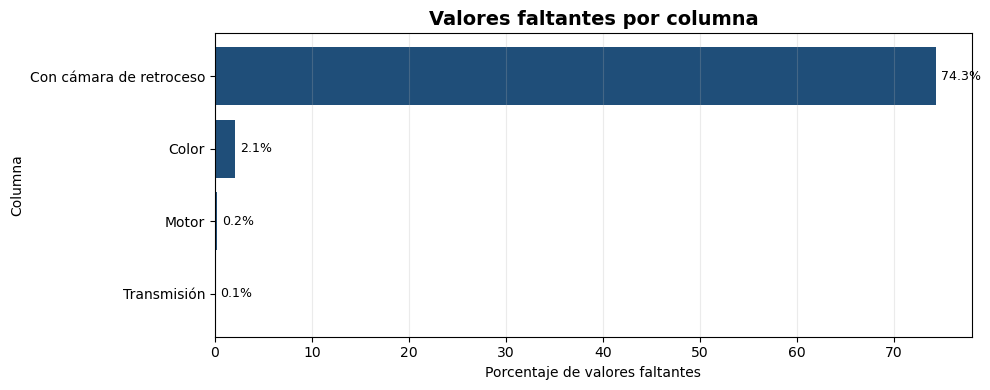

In [16]:
visual.plot_missing_values(dataset)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Categorical Variables
</div>

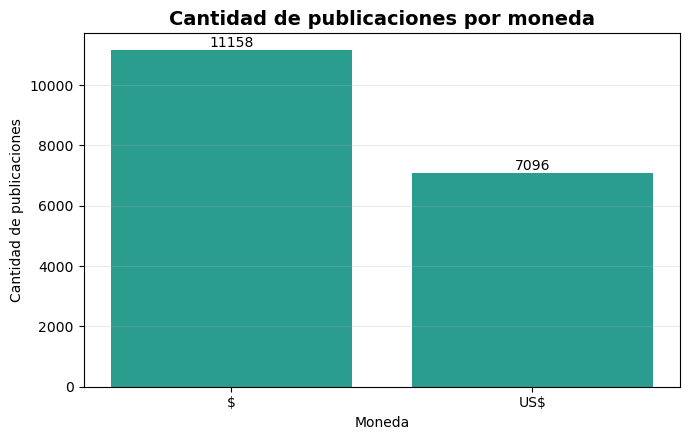

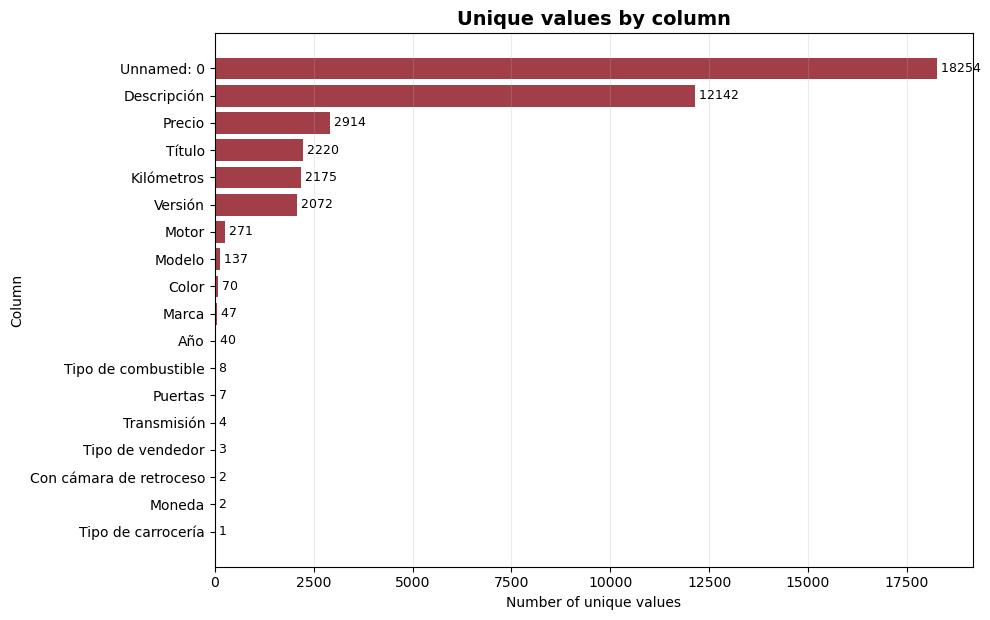

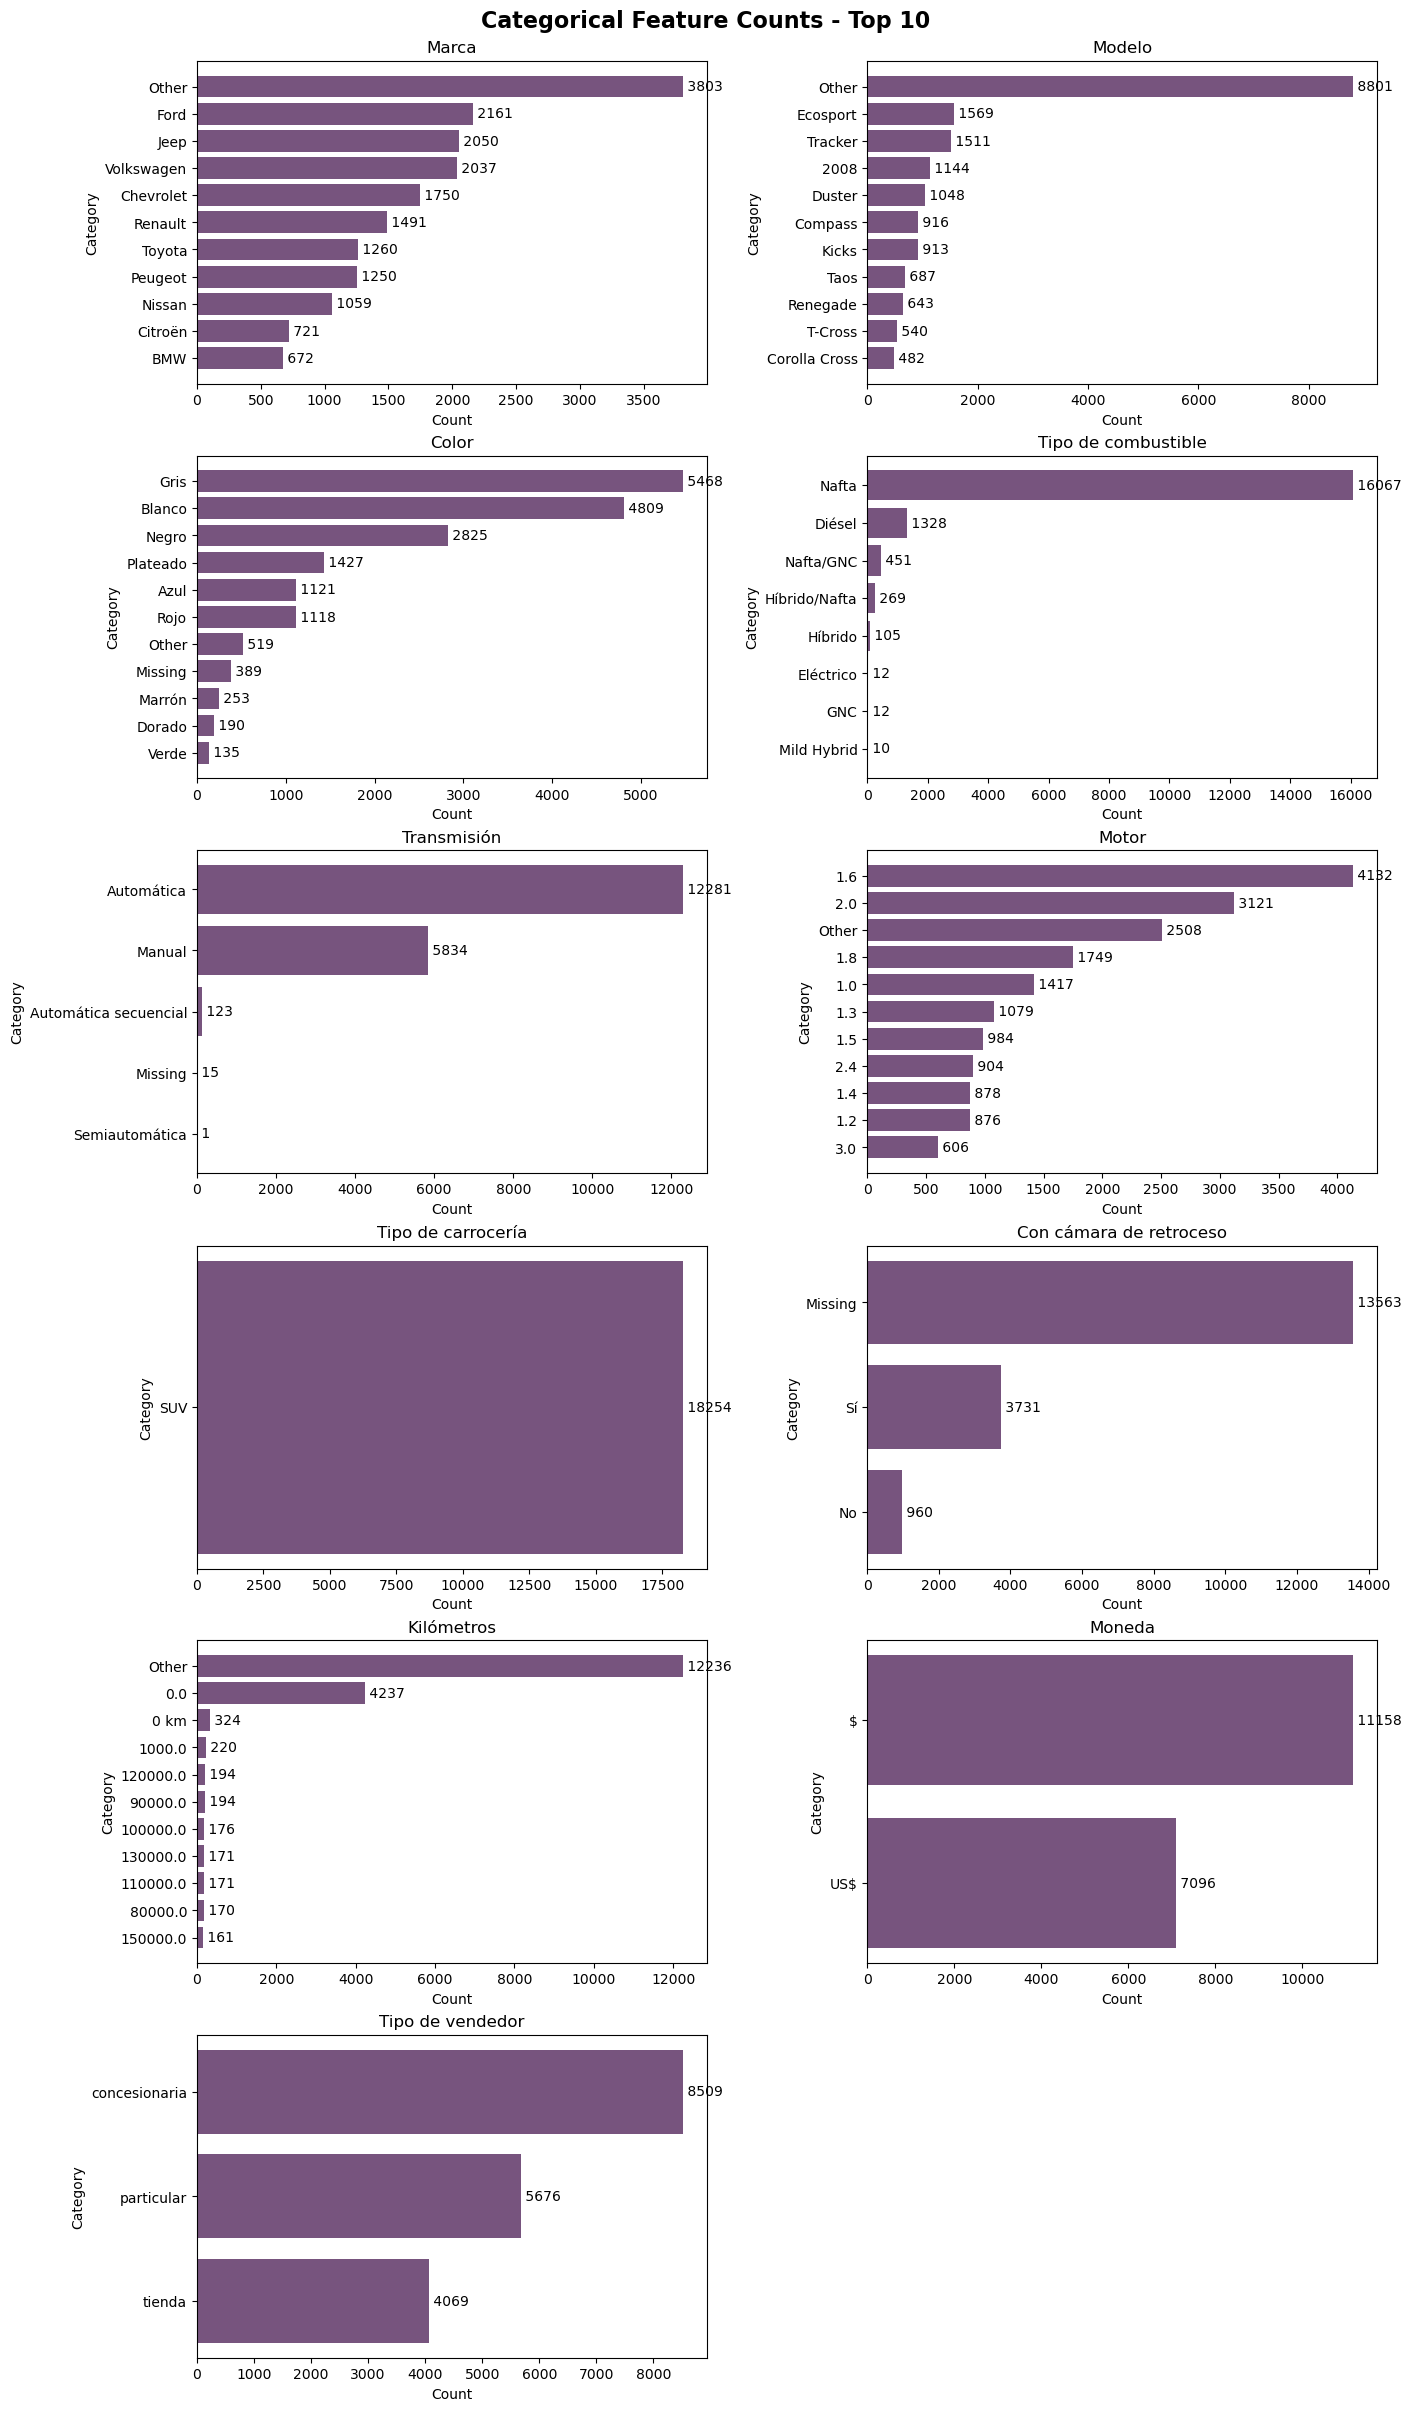

In [17]:
visual.plot_currency_counts(dataset)
visual.plot_unique_values(dataset)
visual.plot_categorical_counts(X, ignored_columns=["Título", "Descripción", "Versión"], top_n = 10, n_cols = 2)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Numerical Variables
</div>

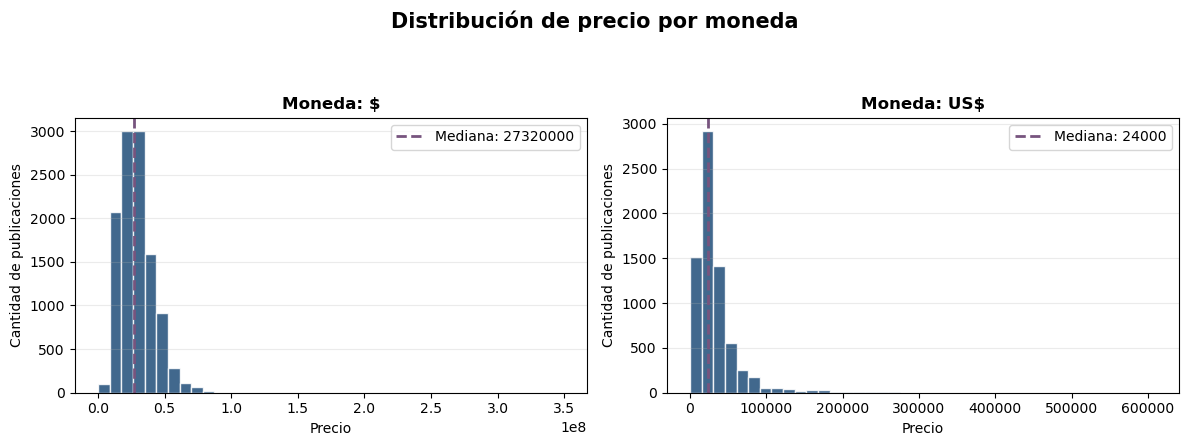

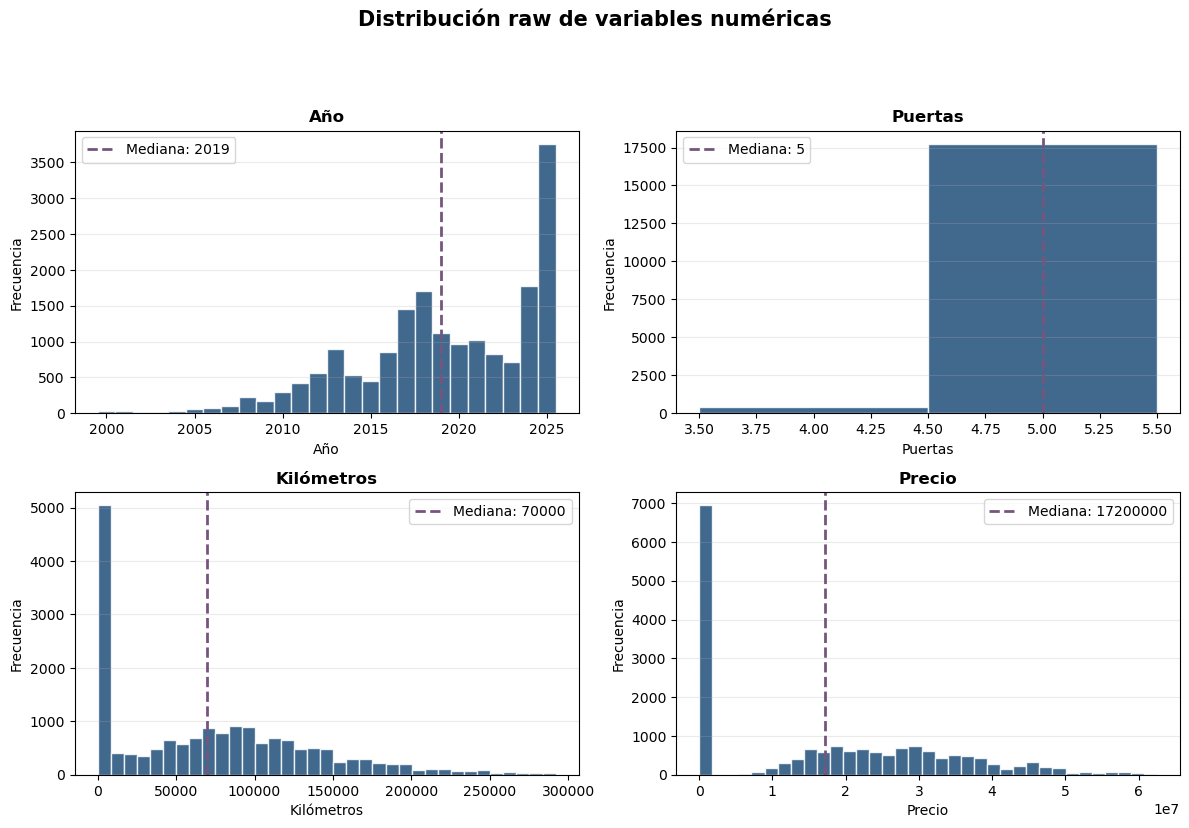

In [18]:
visual.plot_price_distribution_by_currency(dataset)
visual.plot_raw_numeric_distributions(dataset)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Preliminary Outlier Detection
</div>

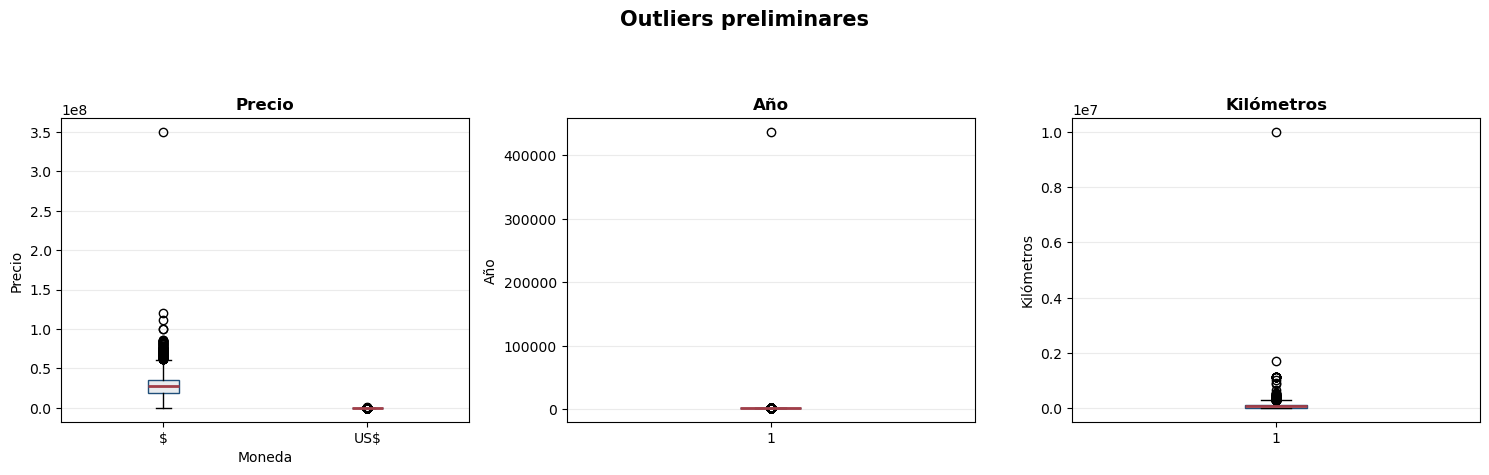

In [19]:
visual.plot_preliminary_outliers(dataset)

En las distribuciones raw se observan algunos valores claramente atípicos que afectan la forma de los gráficos. Por ejemplo, en `Año` aparece un valor imposible y en `Puertas` hay registros con cantidades extremadamente altas. Estos valores hacen que el eje del histograma se estire mucho y que la mayor parte de las observaciones reales quede comprimida en una sola zona.

Por eso, para visualizar mejor las distribuciones, se filtraron los valores extremos solo al momento de graficar, usando percentiles. Esto no implica eliminar datos todavía, sino simplemente evitar que unos pocos outliers deformen el gráfico. La limpieza o corrección definitiva de estos valores se realizará más adelante durante el preprocesamiento.

Con este chequeo se detectan valores incoherentes en dos variables. En `Año` aparece una observación con valor `436694`, claramente mayor al año actual, por lo que se trata de un error de carga. Además, en `Puertas` se observa un valor máximo de `60252`, con 4 observaciones que tienen más de 7 puertas, lo cual tampoco es razonable para este tipo de vehículos.

Como estos casos son pocos y corresponden a valores no interpretables, se podrian eliminar directamente en el preprocesamiento

<h3
style="background-color: #343a40; color: #ffffff; 
display: inline-block; 
padding: 6px 10px;
border-radius: 6px;">
Initial Preprocessing
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Drop irrelevant columns
</div>

En primer lugar, se eliminan aquellas columnas que no aportan información útil para el entrenamiento de los modelos predictivos.

Por un lado, la columna **`Unnamed: 0`** corresponde al índice del dataset exportado a CSV y no contiene información descriptiva sobre los vehículos.

In [20]:
dataset_processed = prep.drop_irrelevant_columns(dataset.copy(), columns_to_drop=["Unnamed: 0"])

Por otro lado, se verifica si existen variables constantes, es decir, columnas cuyos valores son iguales para todas las observaciones. Este tipo de variables no aportan capacidad predictiva, ya que no permiten diferenciar entre ejemplos

In [21]:
constant_columns = eda.get_constant_columns(dataset_processed)
constant_columns

,column,unique_value
0,Tipo de carrocería,SUV


Se observa que la única variable constante del conjunto de datos es **`Tipo de carrocería`**, cuyo valor es **"SUV"** para todas las publicaciones.

Dado que el dataset está compuesto exclusivamente por vehículos SUV, esta variable no aporta información discriminativa y, por lo tanto, se elimina del conjunto de datos.

In [22]:
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Tipo de carrocería"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Remove inconsistent values
</div>

In [23]:
print("=== Chequeo de valores atípicos simples ===")
print(f"Año máximo: {dataset['Año'].max()}")
print(f"Cantidad de años mayores a 2025: {(dataset['Año'] > 2025).sum()}")
print()
print(f"Cantidad máxima de puertas: {dataset['Puertas'].max()}")
print(f"Cantidad de observaciones con más de 5 puertas: {(dataset['Puertas'] > 5).sum()}")

=== Chequeo de valores atípicos simples ===
Año máximo: 436694.0
Cantidad de años mayores a 2025: 1

Cantidad máxima de puertas: 60252.0
Cantidad de observaciones con más de 5 puertas: 9


El chequeo muestra que existe una observación con un valor de **`Año`** igual a **436694**, lo cual no es interpretable como año de fabricación del vehículo.

Además, la variable **`Puertas`** presenta un valor máximo de **60252**, y se detectan observaciones con más de 5 puertas. Dado que estos valores no son razonables para vehículos SUV, se consideran inconsistencias del dataset y se eliminan antes del entrenamiento de los modelos.

In [24]:
range_rules = {
    "Año": {"max": 2025},
    "Puertas": {"max": 5},
}

dataset_processed = prep.remove_invalid_values(dataset_processed, range_rules)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Convert prices to USD
</div>

Para entrenar un modelo predictivo consistente, todos los precios deben estar expresados en una misma moneda. Dado que el dataset contiene publicaciones en pesos argentinos y en dólares estadounidenses, se convierten los precios publicados en pesos a USD.

El dataset fue construido entre el 13/05/2025 y el 30/05/2025. Por este motivo, se utiliza como tipo de cambio el promedio de la cotización diaria del dólar oficial vendedor del Banco Nación durante ese período.

In [25]:
official_usd_sell = {
    "2025-05-13": 1150.00,
    "2025-05-14": 1150.00,
    "2025-05-15": 1150.00,
    "2025-05-16": 1160.00,
    "2025-05-19": 1155.00,
    "2025-05-20": 1160.00,
    "2025-05-21": 1160.00,
    "2025-05-22": 1155.00,
    "2025-05-23": 1150.00,
    "2025-05-26": 1160.00,
    "2025-05-27": 1170.00,
    "2025-05-28": 1175.00,
    "2025-05-29": 1195.00,
    "2025-05-30": 1195.00,
}

In [26]:
EXCHANGE_RATE = sum(official_usd_sell.values()) / len(official_usd_sell)
print(f"El tipo de cambio utilizado es de ${EXCHANGE_RATE:.2f}")

El tipo de cambio utilizado es de $1163.21


In [27]:
dataset_processed = prep.convert_peso_prices_to_usd(dataset_processed, exchange_rate = EXCHANGE_RATE)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Kilometers to int
</div>

Como se observó, la columna `Kilómetros` es un string, por lo que hay que convertirla a float, teniendo en cuenta que algunos, valores incluyen la unidad "km", la cual será eliminada

In [28]:
dataset_processed["Kilómetros"] = (
    dataset_processed["Kilómetros"]
    .apply(prep.extract_first_integer)
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Semantic Cleaning of Categorical Features
</div>

En esta sección se limpian y unifican categorías que representan el mismo valor pero aparecen escritas de distintas formas. Esto incluye diferencias de mayúsculas, tildes, guiones, espacios o variantes semánticamente equivalentes, como `Blanco`, `blanco` y `Blanca`.

Antes de aplicar los cambios, se revisaron las categorías disponibles y se exploraron posibles repeticiones semánticas en variables como `Color`, `Marca`, `Modelo`, `Tipo de combustible`, `Transmisión` y `Motor`. Este análisis permitió decidir qué columnas podían limpiarse con un mapeo manual y cuáles requerían más cuidado para no unir categorías que en realidad representan valores distintos.

Para aplicar los reemplazos se utiliza una función de mapeo semántico. Primero, cada valor se normaliza con `normalize_category_text`, que transforma el texto a minúsculas, elimina tildes, reemplaza guiones y espacios inconsistentes, y deja las categorías en un formato comparable. Luego, `apply_semantic_mapping` usa los mapas definidos manualmente para reemplazar cada variante por una categoría final estandarizada.

Los valores faltantes también se normalizan como la categoría explícita `missing`. Esta decisión permite conservar la información de ausencia como una categoría propia, en lugar de perderla durante el one-hot encoding. En algunas variables, como `Color` o `Transmisión`, que un dato esté faltante puede aportar información sobre la publicación o el tipo de vehículo, por lo que se mantiene como señal disponible para el modelo.

Después de esta limpieza, las columnas categóricas quedan con valores más consistentes y listas para las siguientes etapas de imputación, análisis y codificación.

In [29]:
BRAND_MAP = {
    "renault": ["renault", "rrenault"],
    "hyundai": ["hiunday", "hyundai"],
    "volkswagen": ["volkswagen", "vol"],
    "ds": ["ds", "d.s.", "d·s", "ds automobiles"],
    "land rover": ["range rover", "land rover"],
    "great wall motor": ["gwm", "haval"],
    "volkswagen": ["volkswagen", "vol"],
    "otros": ["alfa romeo", "jac", "jetour", "jetur", "isuzu", "lifan", "lexus", 
              "subaru", "daihatsu", "mini", "kaiyi", "jaguar",],
}

MODEL_MAP = {
    "sw4": ["sw4", "hilux sw4"],
    "ds7": ["ds7", "ds7 crossback"],
    "clase ml": ["clase ml", "ml"],
    "santa fe": ["santa fe", "grand santa fe", "grand santa fé"],
    "tiggo 4": ["tiggo 4", "tiggo 4 pro"],
}

COLOR_MAP = {
    "blanco": ["blanca", "blanco", "blanco glaciar", "summit white", "mineralweiss metallic", "blanco nacre tricapa", "blanco banquise"],
    "negro": ["negra", "negro", "carbon black", "black meet kettle", "noir perla nera"],
    "amarillo": ["amarilla", "amarillo", "amarrillo"],
    "dorado": ["dorada", "dorado", "champaing"],
    "gris": ["gris", "gris plata", "gris platino", "plata", "plateado", "gray", "gris laque", "plata bari", "prata bari+tet vulc", "gris estrella", "gris artense"],
    "gris oscuro": ["gris oscuro", "gris selenium", "grafito", "granite crystal bc", "granite crysta bc", "gris titane", "gris indy", "gris silverstone", "skyscraper grau metallic"],
    "marron": ["marron claro", "marron oscuro", "cafe", "marron kodiak"],
    "azul": ["azul", "steel blue", "blue"],
    "rojo": ["rojo", "rojo sunset metalizado"],
    "verde": ["verde", "verde oscuro"],
    "beige": ["beige", "beige techo negro"],
    "celeste": ["celeste", "azul claro"],
    "naranja": ["naranja", "cobre"],
    "violeta": ["violeta", "morado", "morado oscuro"],
    "bordo": ["bordo"],
    "otros": ["otro", "acero", "rosa", "moundaz", "cendre", "blanco banchisa bicolor negro"]
}

FUEL_TYPE_MAP = {
    "hibrido ": ["hibrido", "hibrido/nafta"]
}

TRANSMISSION_MAP = {
    "automatica ": ["automática", "automatica", "automatica secuencial", "automática secuencial", "semiautomatica", "semiautomática"]
}


In [30]:
dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Marca", 
                                               category_map = BRAND_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Modelo", 
                                               category_map = MODEL_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Color", 
                                               category_map = COLOR_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Tipo de combustible", 
                                               category_map = FUEL_TYPE_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Transmisión", 
                                               category_map = TRANSMISSION_MAP)

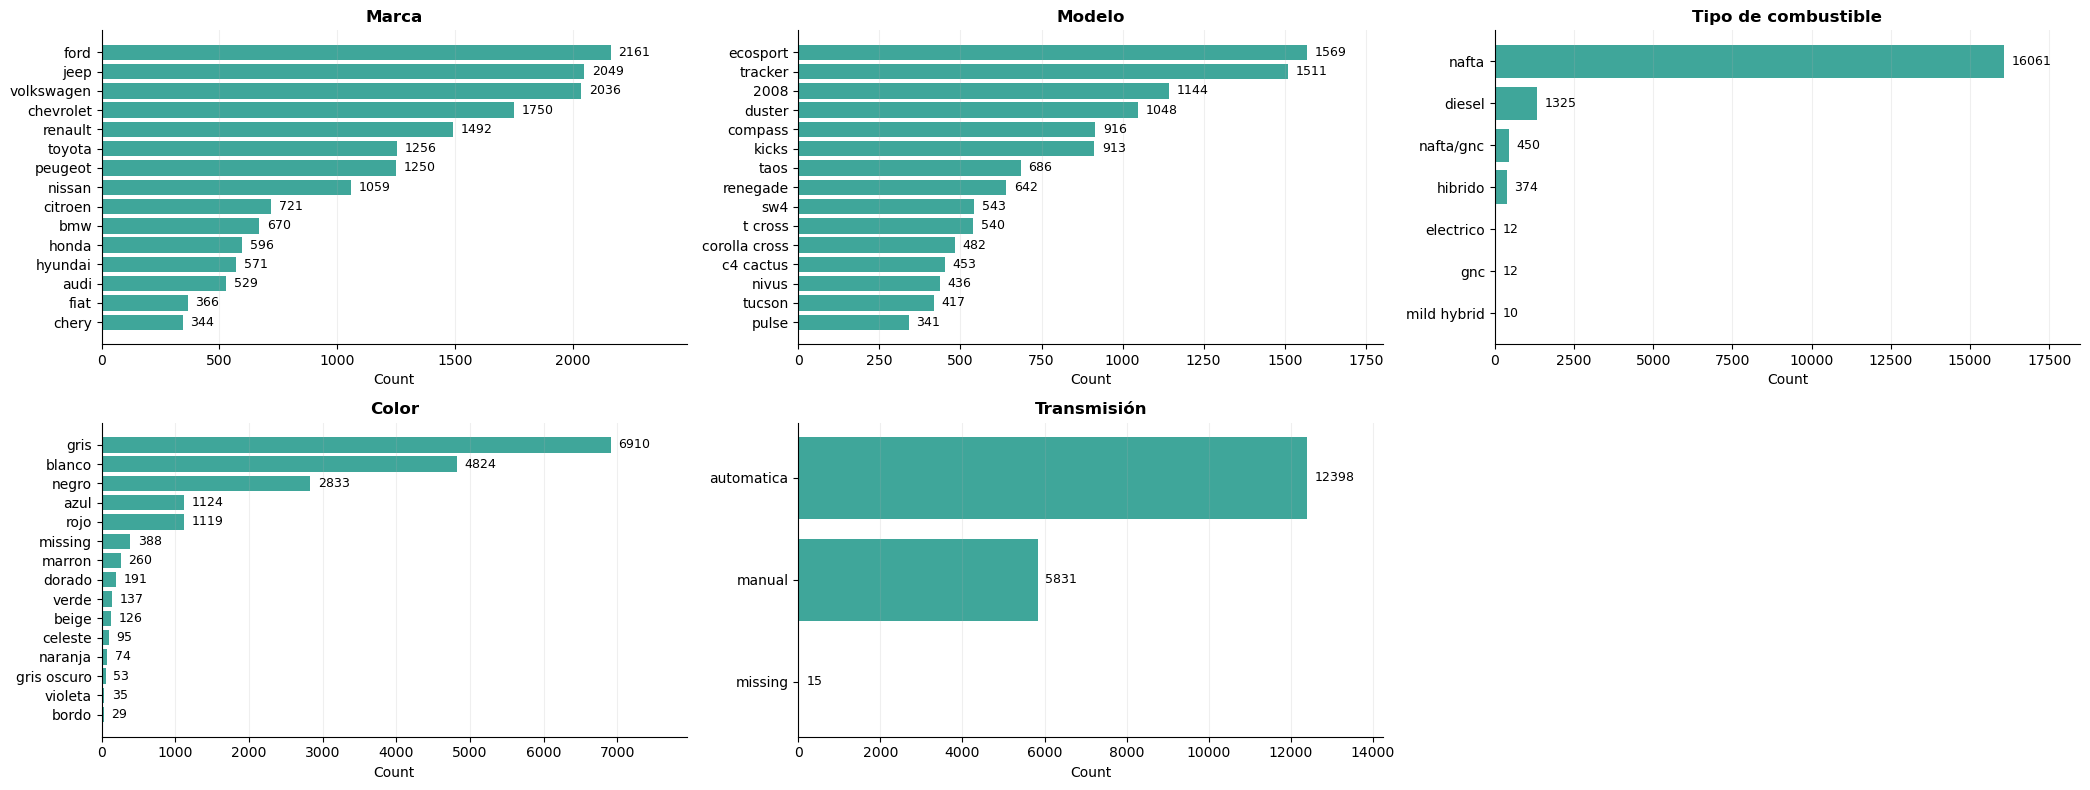

In [31]:
categorical_columns_to_check = [
    "Marca",
    "Modelo",
    "Tipo de combustible",
    "Color",
    "Transmisión",
]

visual.plot_compact_value_counts(
    dataset_processed,
    columns=categorical_columns_to_check,
    top_n=15,
    n_cols=3
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Encode binary features
</div>

Algunas variables categóricas representan información binaria, es decir, valores de tipo **sí/no**. Para que puedan ser utilizadas por los modelos predictivos, estas variables deben transformarse a una representación numérica.

En este caso, la variable **`Con cámara de retroceso`** se codifica como:

- **1** si el vehículo tiene cámara de retroceso
- **0** si el vehículo no tiene cámara de retroceso

In [32]:
camera_map = {
    "sí": 1,
    "si": 1,
    "no": 0,
}

dataset_processed = prep.map_column_values(dataset_processed, column = "Con cámara de retroceso", value_map = camera_map)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Missing Value Handling
</div>

En esta sección se revisan algunos valores faltantes que pueden recuperarse a partir de información textual disponible en otras columnas del dataset, principalmente `Título`, `Descripción` y `Versión`.

No se imputan todos los valores faltantes, sino únicamente aquellos casos en los que el texto contiene una señal explícita y suficientemente clara. Para variables categóricas, como `Color` y `Transmisión`, primero se buscan menciones de categorías conocidas luego de aplicar la misma normalización semántica usada en la limpieza previa. Si se detecta una única categoría, el valor se completa; si aparecen varias categorías posibles, el caso se mantiene sin imputar para evitar asignaciones ambiguas.

Para variables con una estructura más específica, como `Motor` o `Con cámara de retroceso`, se usan extractores diseñados para detectar patrones concretos dentro del texto. En `Motor`, se buscan valores de cilindrada y señales de turbo. En `Con cámara de retroceso`, solo se completa el valor cuando aparece una mención explícita de la cámara.

Este criterio permite recuperar información que ya estaba presente en la publicación sin introducir imputaciones estadísticas todavía. Los valores que no puedan recuperarse con suficiente confianza se mantienen como faltantes o como categoría `missing`, y se revisan más adelante según su relevancia para el modelado.

### Color
Se buscan menciones de colores en las columnas de texto y se completan únicamente los casos con una sola categoría detectada.

In [33]:
color_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Color",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=COLOR_MAP,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

color_row_mentions

,row_index,Color_is_missing,matched_categories,n_category_mentions
0,4407,True,azul,1
1,4476,True,blanco | negro,2
2,6776,True,gris,1
3,8804,True,beige,1
4,10789,True,blanco | negro,2
5,10884,True,azul,1
6,11095,True,blanco | gris | gris oscuro | negro,4
7,11460,True,blanco | negro,2
8,13138,True,negro,1
9,13220,True,gris | negro,4


In [34]:
dataset_processed, color_fill_audit = prep.fill_missing_from_single_text_match(
    dataset_processed,
    target_col="Color",
    matches_df=color_row_mentions,
)

color_fill_audit

Missing rows in 'Color': 388
Filled from text matches: 8
Still missing after text matches search: 380


,row_index,matched_categories,n_unique_matches,fill_value,target_col
85,4407,azul,1.0,azul,Color
141,6776,gris,1.0,gris,Color
173,8804,beige,1.0,beige,Color
216,10884,azul,1.0,azul,Color
269,13138,negro,1.0,negro,Color
315,14804,blanco,1.0,blanco,Color
325,15343,gris,1.0,gris,Color
353,16483,blanco,1.0,blanco,Color


### Motor
Se extrae información de cilindrada desde el texto y se conserva la señal de turbo cuando aparece explícitamente.

In [35]:
ENGINE_TEXT_MAP = {
    "1.0": [
        "1.0",
        "1.0t",
        "1.0 t",
        "1.0 tsi",
        "1.0 200 tsi",
    ],
    "1.3": [
        "1.3",
        "1.3 tce",
        "1.3 tce turbo",
        "1.3 t270",
    ],
    "1.5": [
        "1.5",
        "1.5t",
        "1.5 t",
        "1.5 turbo",
    ],
    "1.6": [
        "1.6",
        "1.6l",
        "1.6 16v",
        "1.6 vti",
        "1.6 thp",
    ],
    "1.8": [
        "1.8",
    ],
    "2.0": [
        "2.0",
        "2.0 sport",
        "2.0 sel",
        "2.0 hse",
        "2.0 turbo",
        "2.0 turbonaftero",
    ],
    "2.5": [
        "2.5",
    ],
    "2.8": [
        "2.8",
    ],
}

In [36]:
engine_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Motor",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=ENGINE_TEXT_MAP,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

engine_row_mentions

,row_index,Motor_is_missing,matched_categories,n_category_mentions
0,209,True,2.5,2
1,219,True,1.0,4
2,2488,True,1.6,2
3,2764,True,1.8,3
4,3624,True,1.5,6
5,3760,True,1.6,4
6,4418,True,1.6,4
7,6095,True,1.5,3
8,7915,True,1.5,2
9,8264,True,1.0,2


In [37]:
dataset_processed, engine_audit = prep.fill_missing_from_text(
    dataset_processed,
    target_col="Motor",
    text_cols=("Versión", "Título", "Descripción"),
    extractor=prep.extract_engine_liters_from_text,
    extracted_col_name="extracted_engine",
)

engine_audit.head(10)

Missing rows in 'Motor': 38
Filled from text: 21
Still missing after text search: 17


,row_index,text_used,extracted_engine,was_missing,was_filled
0,209,4X2 Hibrida AT Ford Kuga 2.5 Hibrida 4x2 At 2020 Ford Kuga 2.5 Hibrida 4X2 At 2020 con 45000 km. Oportunidad!!Unida...,2.5,True,True
1,219,1.0 200 Tsi Highline Tip Volkswagen T-Cross 1.0 200 Tsi Highline Tip Descubrí nuestro impresionante Volkswagen T-Cr...,1.0 turbo,True,True
2,2488,"1.6 S 110cv 4x2 Ford Ecosport 1.6 S 110cv 4x2 Descubre nuestro impresionante Ford Eco Sport del año 2017, en color ...",1.6,True,True
3,2764,1.8 4x2 Sport Jeep Renegade 1.8 4x2 Sport Somos ExpoUsados de San Luis Jeep Renegade 1.8 4X2 Sport 2018 con 62297 k...,1.8,True,True
4,3624,"1.5 Turbo LX 4x2 Honda Cr-v 1.5 Turbo Lx 4x2 Honda CRV LX 4X2 1.5 turbo 191cv, Blanco perlado, entrega inmdata",1.5 turbo,True,True
5,3760,1.6 Thp 165 At6 Shine Citroën C4 Cactus 1.6 Thp 165 At6 Shine Descubrí nuestro impresionante Citroen C 4 Cactus del...,1.6 turbo,True,True
6,4418,"1.6 Vti 115 X-series Citroën C4 Cactus 1.6 Vti 115 X-series * ¡TU AUTO USADO, PARA RPM VALE MAS!Pagamos más por tu ...",1.6,True,True
7,6095,1.5t Titanium Ford Territory 1.5t Titanium Usados | dietrich • Marca: Ford• Modelo: Territory Titanium 1.5t Cvt• Añ...,1.5,True,True
8,7915,"1.5t Titanium Ford Territory 1.5t Titanium Descubre nuestro impresionante Ford Territory del año 2022, en color Bla...",1.5,True,True
9,8264,1.0T Gt Peugeot 2008 1.0t Gt El vendedor no incluyó una descripción del producto,1.0,True,True


### Transmisión
Se buscan variantes textuales de transmisión manual o automática y se imputan solo los casos no ambiguos.

In [38]:
TRANSMISSION_MAP_TEXT = {
    "automatica": [
        "automatica",
        "automatico",
        "caja automatica",
        "at",
        "at6",
        "at8",
        "at9",
        "cvt",
        "dsg",
        "tiptronic",
        "secuencial",
    ],
    "manual": [
        "manual",
        "caja manual",
        "mt",
    ],
}

In [39]:
transmission_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Transmisión",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=TRANSMISSION_MAP_TEXT,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

transmission_row_mentions

,row_index,Transmisión_is_missing,matched_categories,n_category_mentions
0,2194,True,automatica,2
1,5507,True,automatica,2
2,7663,True,automatica,4
3,12920,True,automatica,2
4,12979,True,automatica,2
5,17594,True,automatica,4
6,17665,True,automatica | manual,8


In [40]:
dataset_processed, transmission_fill_audit = prep.fill_missing_from_single_text_match(
    dataset_processed,
    target_col="Transmisión",
    matches_df=transmission_row_mentions,
)

transmission_fill_audit

Missing rows in 'Transmisión': 15
Filled from text matches: 6
Still missing after text matches search: 9


,row_index,matched_categories,n_unique_matches,fill_value,target_col
1,2194,automatica,1.0,automatica,Transmisión
2,5507,automatica,1.0,automatica,Transmisión
5,7663,automatica,1.0,automatica,Transmisión
10,12920,automatica,1.0,automatica,Transmisión
11,12979,automatica,1.0,automatica,Transmisión
13,17594,automatica,1.0,automatica,Transmisión


### Con cámara de retroceso

Se completa la variable únicamente cuando el texto menciona explícitamente la presencia de cámara de retroceso.

In [41]:
CAMARA_MAP = {
    "Camara de retroceso": ["Cámara de retroceso", "Camara de retroceso"]
}

In [42]:
camera_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Con cámara de retroceso",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=CAMARA_MAP,
    only_missing_target=True,
    only_rows_with_mentions=True,
)

camera_row_mentions

,row_index,Con cámara de retroceso_is_missing,matched_categories,n_category_mentions
0,4,True,camara de retroceso,1
1,45,True,camara de retroceso,1
2,54,True,camara de retroceso,1
3,175,True,camara de retroceso,1
4,269,True,camara de retroceso,1
...,...,...,...,...
209,17684,True,camara de retroceso,1
210,17787,True,camara de retroceso,1
211,17824,True,camara de retroceso,1
212,17825,True,camara de retroceso,1


In [43]:
dataset_processed, camera_audit = prep.fill_missing_from_text(
    dataset_processed,
    target_col="Con cámara de retroceso",
    text_cols=("Título", "Descripción", "Versión"),
    extractor=prep.extract_backup_camera,
    extracted_col_name="extracted_camera",
)

camera_audit.head(10)

Missing rows in 'Con cámara de retroceso': 13556
Filled from text: 486
Still missing after text search: 13070


,row_index,text_used,extracted_camera,was_missing,was_filled
0,4,Jeep Compass 2.4 Sport At •Unico dueño•Todos los services oficiales•Bateria nueva•2 juegos de alfombras•Caja Automa...,1.0,True,True
1,36,Mercedes-Benz Clase GLE GLE 450 4MATIC (MHEV) Desde AutoPremium Usados Seleccionados tenemos para ofrecerte una MER...,1.0,True,True
2,45,"Kia Sorento 2.5 Ex Crdi 170 Hp At Kia sorento motor 2.5 de 170 hp estéreo sistema Android, bluetooth, gps,cámara de...",1.0,True,True
3,54,Toyota RAV4 2.5 4x4 6at TOYOTA RAV4 VX 2.5l 4x4 AT - modelo 2013- segundo dueño 136.000km- motor 2.5l (cadenero)- t...,1.0,True,True
4,86,BMW X3 2.0 Xdrive 30E Xline Descripción!!!!Desde AutoPremium Usados Seleccionados tenemos para ofrecerte un BMW X3 ...,1.0,True,True
5,155,Audi Q3 1.4 Tfsi Stronic 150 Cv Audi Q3 35 TFSI35 TFSI corresponde a motor 1.4 TFSI de 150CV- Audi drive select- Au...,1.0,True,True
6,175,"Chery Tiggo 2.0 F2 Confort 4x2 138cv Chery Tiggo 2014, con GNC,luces led y estero Pionner, se entrega con la camara...",1.0,True,True
7,225,"Toyota Corolla Cross 2.0 Seg Cvt Toyota Corolla Cross 2025 - 21 km, retirado de agencia y guardado en garage, la má...",1.0,True,True
8,230,Chevrolet Equinox 1.5t Premier 4wd CHEVROLET EQUINOX 1.5T PREMIER AWD AT 2019 / 58.582 KM / EXCELENTE ESTADO con CU...,1.0,True,True
9,269,Jeep Commander 1.3 T270 Limited 4X2 At6 ANTICIPO + CUOTASFINANCIACIÓN PRE CANCELABLELlantas de aleación 18”.Sist. m...,1.0,True,True


### Checking updated dataset

In [44]:
# previous missing values
eda.missing_values_summary(dataset)

,column,missing_count,missing_percentage
0,Con cámara de retroceso,13563,74.30
1,Color,389,2.13
2,Motor,38,0.21
3,Transmisión,15,0.08


In [45]:
# Current missing values
eda.missing_values_summary(dataset_processed)

,column,missing_count,missing_percentage
0,Con cámara de retroceso,13070,71.64
1,Color,380,2.08
2,Motor,17,0.09
3,Transmisión,9,0.05


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
New Columns to Represent Engine Feature
</div>

Para la variable `Motor`, se busca extraer información técnica que aparece escrita de distintas formas en el texto original. En particular, se recupera la cilindrada del motor y se conserva la presencia de turbo cuando esta información aparece explícitamente mencionada.

Ya se completaron algunos valores faltantes de `Motor` utilizando las columnas `Título`, `Descripción` y `Versión`. Para esto se identifican patrones confiables de cilindrada, como `1.6`, `2.0`, `1.5t`, `1.3 TCE`, `1.0 TSI` o valores en centímetros cúbicos como `1600 cc`. Cuando además se detectan expresiones asociadas a turbo, como `turbo`, `TSI`, `TDI`, `THP` o `TCE`, el valor imputado conservó esa información en el texto, por ejemplo `1.5 turbo`.

Luego, a partir de la columna `Motor` ya completada, se crean nuevas variables. La columna `Cilindrada` almacena la cilindrada extraída en litros como valor numérico, mientras que `Tiene turbo` indica si el motor presenta señales de turbo en el texto. Además, se genera `Grupo cilindrada`, una variable ordinal que resume la cilindrada en rangos ordenados para facilitar su uso posterior en análisis y modelado.

De esta forma, la información técnica contenida originalmente en `Motor` queda representada en columnas más limpias y comparables. Una vez creadas estas variables derivadas, la columna original `Motor` puede eliminarse del dataset final.

In [46]:
TURBO = [
    "turbo",
    "turboalimentado",
    "tsi",
    "tdi",
    "tfsi",
    "ecoboost",
    "tce",
    "thp",
    r"\bt\b", # Match 't' as a whole word
    r"\d\.\d\s*t\b", # Match patterns like '1.6 T'
]

In [47]:
dataset_processed["Cilindrada"] = dataset_processed["Motor"].apply(prep.extract_engine_liters)
dataset_processed["Cilindrada"].isna().sum()

np.int64(311)

Algunas columas de `Motor` solo decian cosas como "Turboalimentado", por lo que tienen NAN a la hora de completar la cilindrada. Esos valores los podemos recuperar de las columnas `Versión` y `Descripción`

In [48]:
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Versión"].apply(prep.extract_engine_liters)
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Descripción"].apply(prep.extract_engine_liters)

In [49]:
print(dataset_processed["Cilindrada"].isna().sum())
print(dataset_processed["Cilindrada"].head())

22
0    1.5
1    2.0
2    1.4
3    1.5
4    2.4
Name: Cilindrada, dtype: float64


In [50]:
dataset_processed["Grupo cilindrada"] = dataset_processed["Cilindrada"].apply(prep.encode_engine_size)
dataset_processed["Tiene turbo"] = dataset_processed["Motor"].apply(lambda value: prep.has_turbo(value, turbo_patterns = TURBO))

In [51]:
# Deleting Motor column as it has been processed into new features
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Motor"])

In [52]:
print(dataset_processed["Grupo cilindrada"].value_counts())
print(dataset_processed["Grupo cilindrada"].isna().sum())

Grupo cilindrada
2    7412
3    5057
1    2462
4    2061
5    1230
0      22
Name: count, dtype: int64
0


In [53]:
dataset_processed["Tiene turbo"].value_counts()

Tiene turbo
0    17874
1      370
Name: count, dtype: int64

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Text-Based Condition Features
</div>

Las columnas `Título`, `Descripción` y `Versión` tienen bastante información escrita por los vendedores. Parte de esa información ya la usamos para completar valores faltantes, como `Color`, `Motor`, `Transmisión` o `Con cámara de retroceso`.

Antes de eliminar estas columnas, se busca rescatar algunas señales simples que pueden ser útiles para predecir el precio. En vez de aplicar un modelo de NLP más complejo, se define un conjunto de palabras y frases de interés y se crean variables binarias que indiquen si esas expresiones aparecen o no en la publicación.

In [54]:
eda.frequent_words_table(
    dataset_processed,
    text_cols=("Título", "Descripción", "Versión"),
    top_n=50
)

,word,count
0,000,7497
1,4x2,6118
2,cvt,4754
3,usado,4502
4,jeep,4004
5,volkswagen,3913
6,estado,3893
7,tsi,3851
8,usados,3845
9,4x4,3840


Teniendo un paneo general de las palabras más frecuengtes, vemos hay gran variedad de tipos de palabra. Muchas de estas están relacionadas al auto como producto, pero no hablan mucho del estado. Por eso, podríamos buscar la frecuencia de palabras agrupadas según el tipo de información que representan. Por ejemplo, algunas expresiones hacen referencia a documentación o papeles al día, otras a services o mantenimiento, otras al buen estado del vehículo, y otras a posibles detalles o daños. Vamos a gregar columnas binarias que representen estas condiciones.

Tambien, agregaremos una columna para identificar las publicaciones en las que no aparece ninguna de estas señales. Esto permite diferenciar entre autos con alguna información textual relevante y publicaciones donde el texto no aporta demasiado en este sentido.

In [55]:
INTEREST_TERMS = {
    "papeles": [
        "papeles al dia",
        "documentacion al dia",
        "documentacion en regla",
        "listo para transferir",
        "lista para transferir",
        "sin deudas",
        "libre deuda",
        "libre de deuda",
        "vtv",
        "verificacion policial",
    ],
    "service": [
        "service",
        "services",
        "service oficial",
        "services oficiales",
        "mantenimiento",
        "distribucion hecha",
        "bateria nueva",
        "cubiertas nuevas",
    ],
    "buen_estado": [
        "buen estado",
        "muy buen estado",
        "excelente estado",
        "excelentes condiciones",
        "buenas condiciones",
    ],
    "impecable": [
        "impecable",
        "impecables",
        "sin detalles",
        "como nuevo",
        "como nueva",
        "como 0km",
    ],
    "cuidado": [
        "cuidado",
        "cuidada",
        "muy cuidado",
        "muy cuidada",
        "bien cuidado",
        "bien cuidada",
    ],
    "detalles_uso": [
        "detalles de uso",
        "detalle de uso",
        "detalles esteticos",
        "detalle estetico",
    ],
    "daño": [
        "rayado",
        "rayada",
        "rayones",
        "golpe",
        "golpes",
        "golpeado",
        "golpeada",
        "abollado",
        "abollada",
        "abolladura",
    ],
    "sin_choque": [
        "sin choque",
        "sin choques",
        "nunca chocado",
        "nunca chocada",
    ],
}

In [56]:
eda.count_interest_terms_in_text(
    dataset_processed,
    text_cols=("Título", "Descripción", "Versión"),
    terms_map=INTEREST_TERMS,
)

,term,count,row_count
0,papeles,3819,2842
1,service,3503,2611
2,buen_estado,2918,2299
3,impecable,1998,1748
4,cuidado,957,530
5,daño,69,65
6,detalles_uso,61,61
7,sin_choque,34,34


In [57]:
dataset_processed = prep.add_text_indicator_features(
    dataset_processed,
    text_cols=("Título", "Descripción", "Versión"),
    terms_map=INTEREST_TERMS,
    add_no_match_feature=True,
    no_match_feature_name="sin_condicion",
)

In [58]:
dataset_processed.columns

Index(['Marca', 'Modelo', 'Año', 'Versión', 'Color', 'Tipo de combustible', 'Puertas', 'Transmisión', 'Con cámara de retroceso', 'Kilómetros', 'Título', 'Precio', 'Descripción',
       'Tipo de vendedor', 'Cilindrada', 'Grupo cilindrada', 'Tiene turbo', 'papeles', 'service', 'buen_estado', 'impecable', 'cuidado', 'detalles_uso', 'daño', 'sin_choque',
       'sin_condicion'],
      dtype='str')

Estas variables no dicen por sí solas si el precio debería subir o bajar. Por ejemplo, una mención a `service` o `impecable` podría estar asociada a un mejor estado del auto, mientras que una mención a `rayones` o `golpes` podría indicar lo contrario. La idea es dejar que el modelo aprenda esa relación a partir de los datos.

Una vez extraídas estas señales, las columnas originales de texto ya no se van a usar directamente, entonces las sacamos.

In [59]:
dataset_processed = prep.drop_irrelevant_columns(dataset_processed,columns_to_drop=["Título", "Descripción", "Versión"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Final Missing Value Encoding
</div>

Antes de separar el dataset y aplicar one-hot encoding, se completan los valores faltantes restantes en las variables categóricas. En lugar de eliminar estas observaciones o imputarlas con una categoría mayoritaria, se reemplaza cada faltante por una categoría explícita asociada a su columna.

Por ejemplo, un valor faltante en `Color` se reemplaza por `missing_Color`, mientras que un faltante en `Transmisión` se reemplaza por `missing_Transmisión`. Esto permite conservar la información de que el dato no estaba disponible, y deja que el modelo aprenda si esa ausencia tiene alguna relación con el precio.

In [60]:
dataset_processed = prep.fill_missing_with_value(dataset_processed)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Data Splitting
</h3>

Una vez terminadas las transformaciones y la recuperación de información desde texto, se separa el dataset en entrenamiento y validación (80% - 20%)

El split se realiza estratificando por `Marca`, ya que esta variable tiene una distribución desigual y suponemos    que está fuertemente relacionada con el precio. Mantener proporciones similares de marcas en train y validation ayuda a que ambos conjuntos sean más comparables.

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Stratified by Brand
</div>

In [61]:
X_pp = dataset_processed.drop(columns = [TARGET])
y_pp = dataset_processed[TARGET]

In [62]:
train_set, val_set = split.train_val_split_stratified(X_pp, y_pp, stratify_by = X_pp["Marca"], train_size = 0.80)

X_train, y_train = train_set
X_val, y_val = val_set

In [63]:
# Split check
display(split.split_size_summary(X_train, X_val))

,split,rows,percentage
0,train,14597,80.01
1,validation,3647,19.99


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">

</h3>

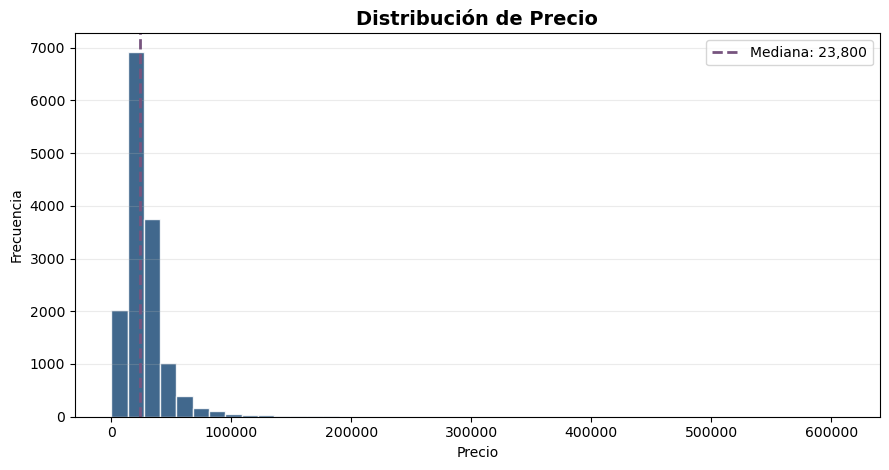

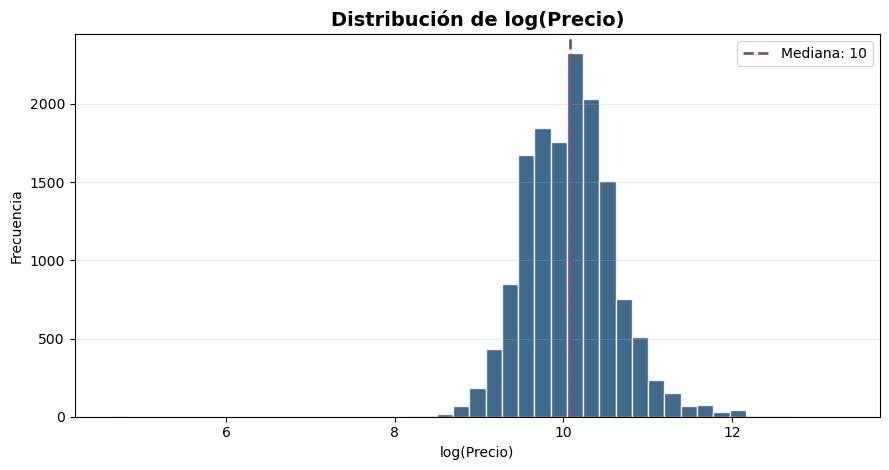

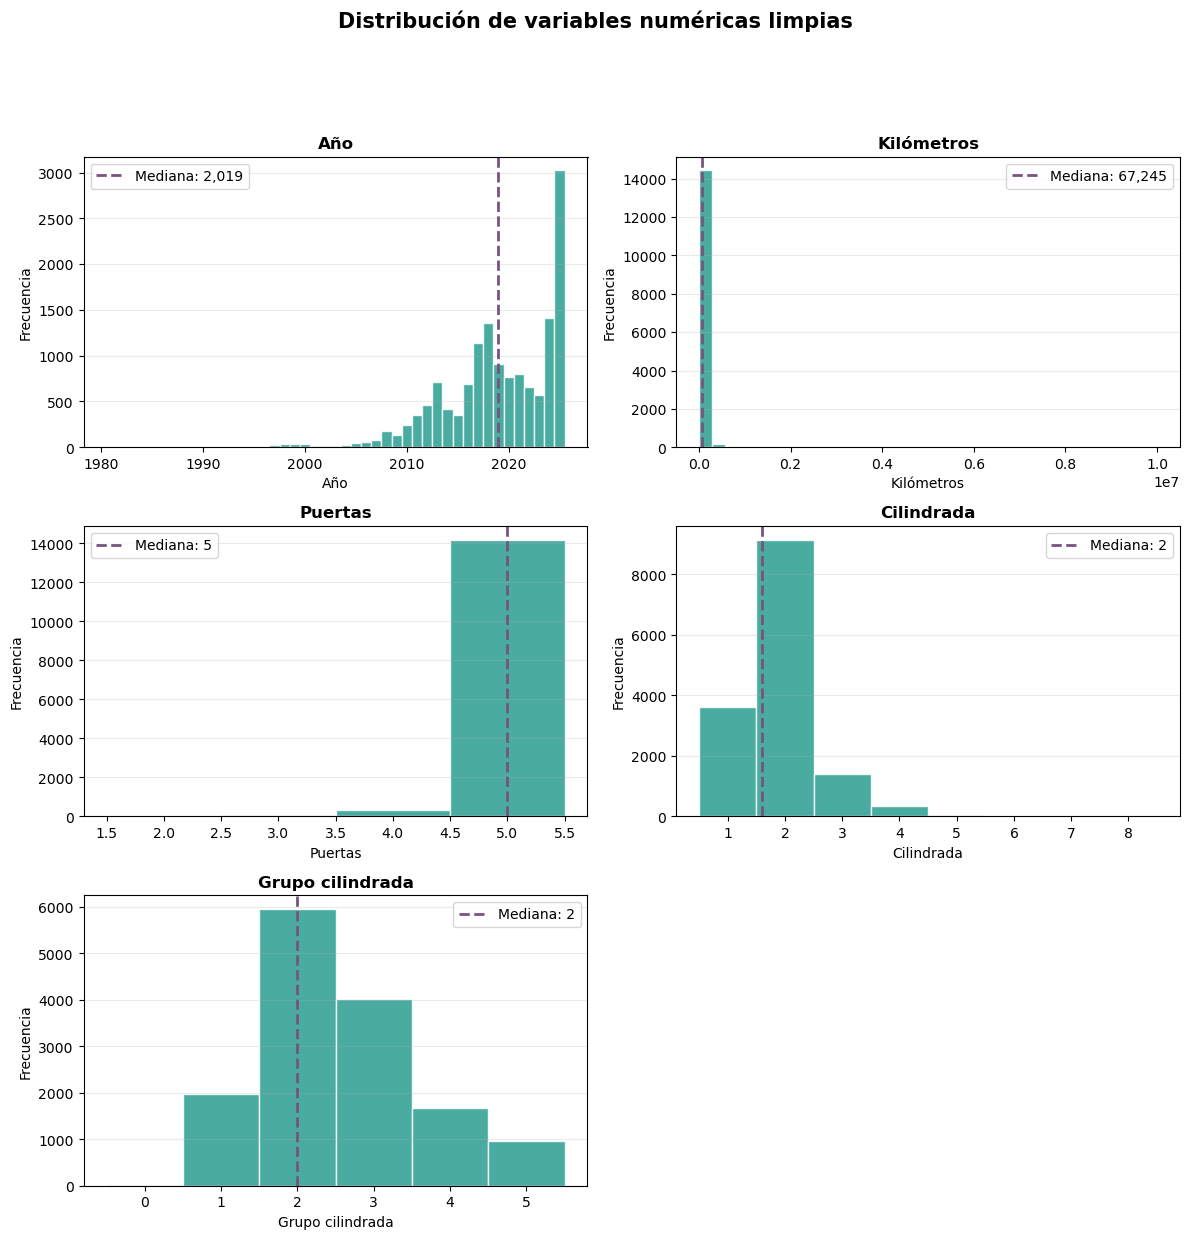

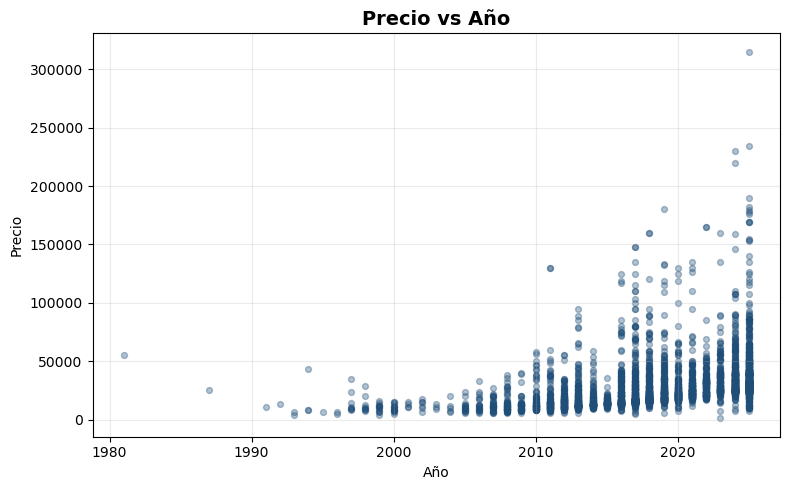

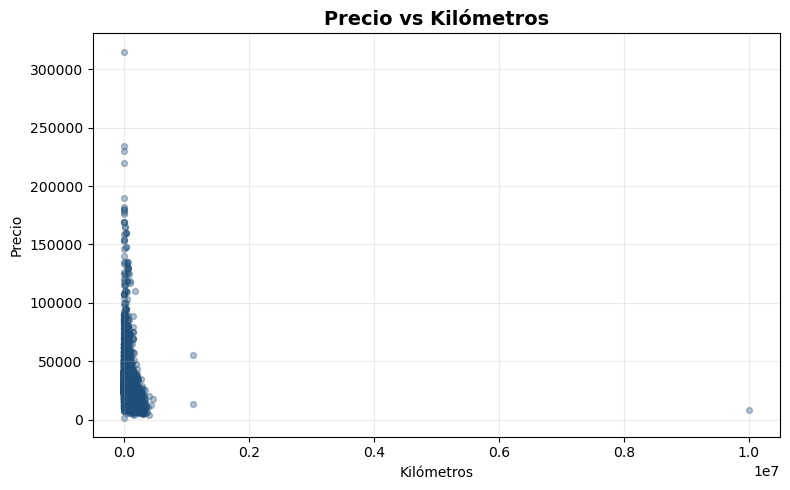

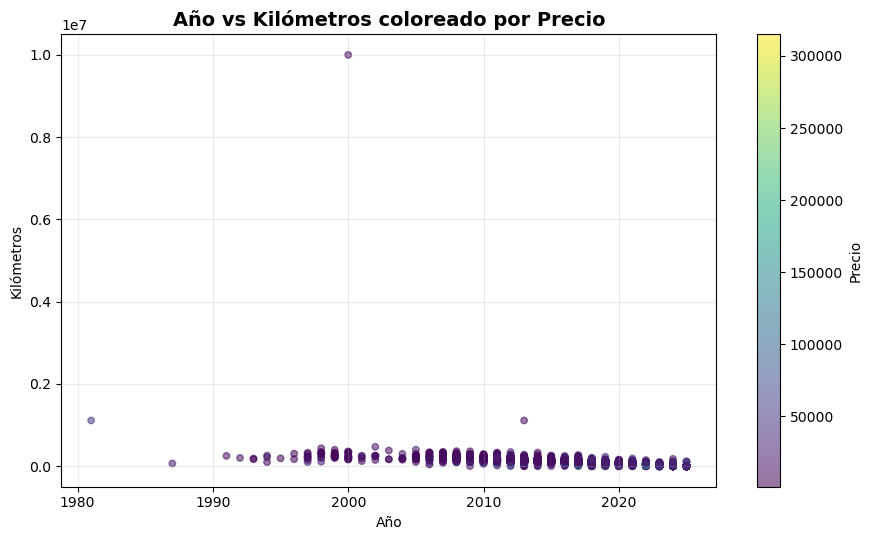

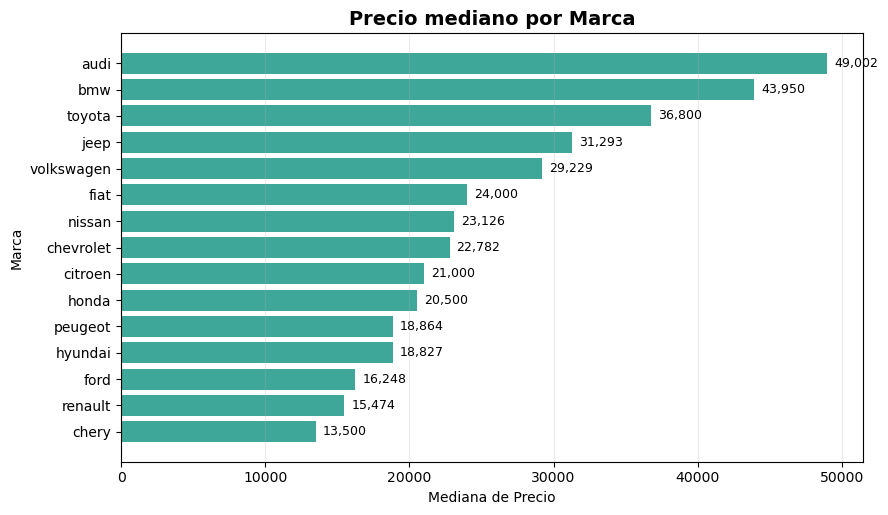

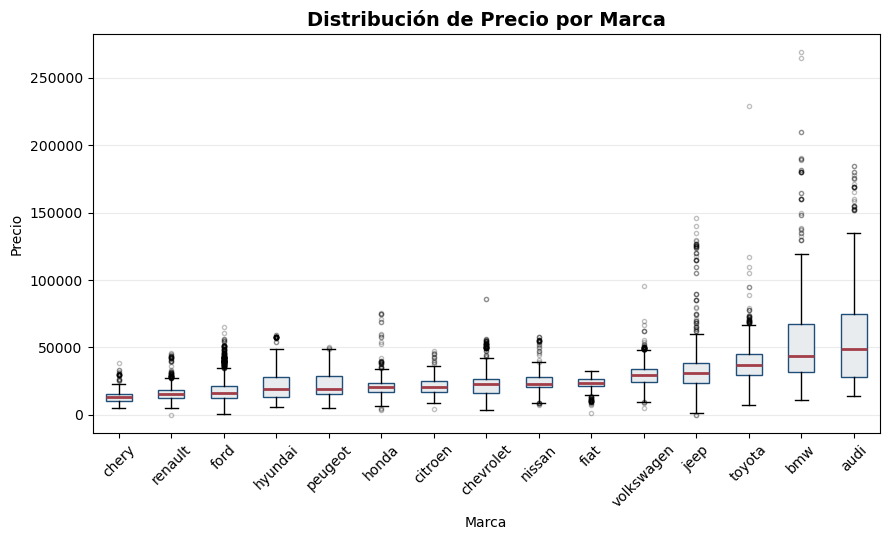

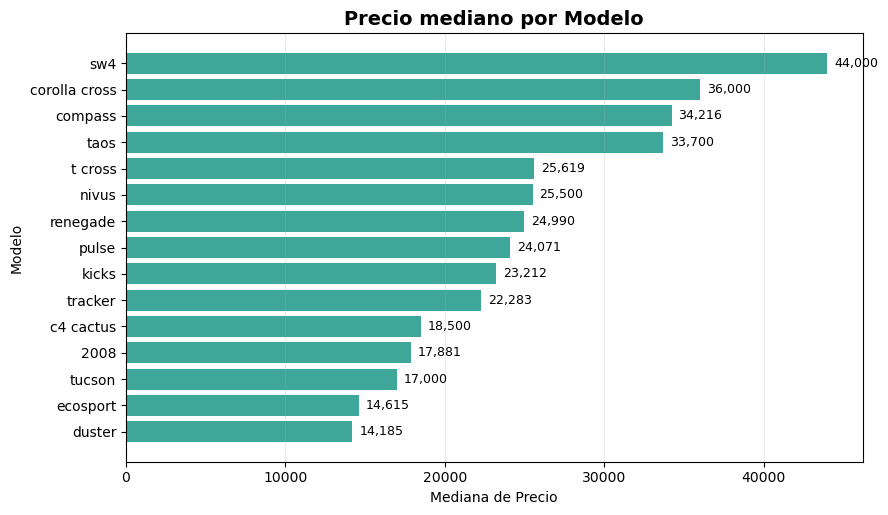

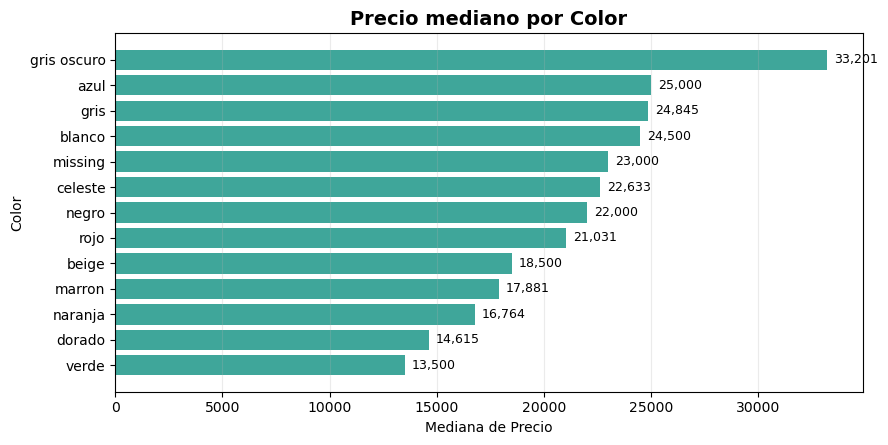

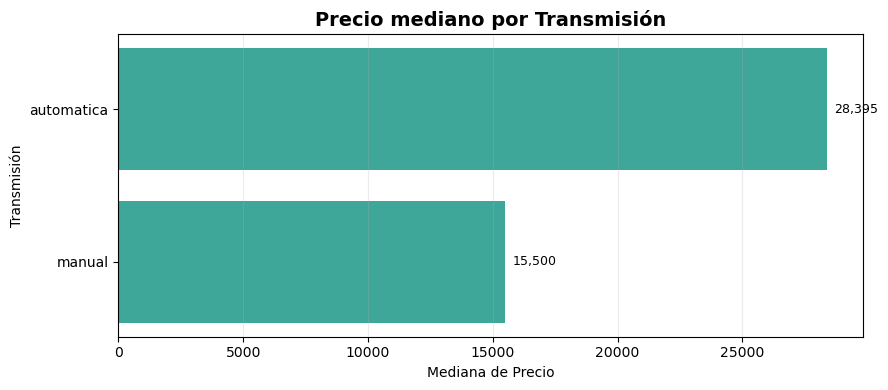

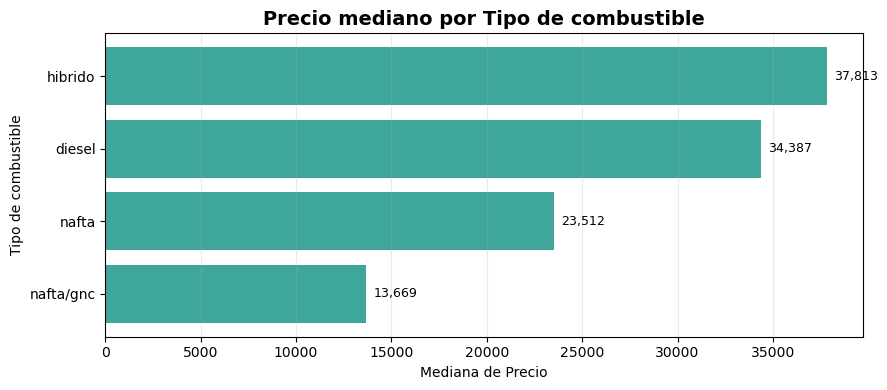

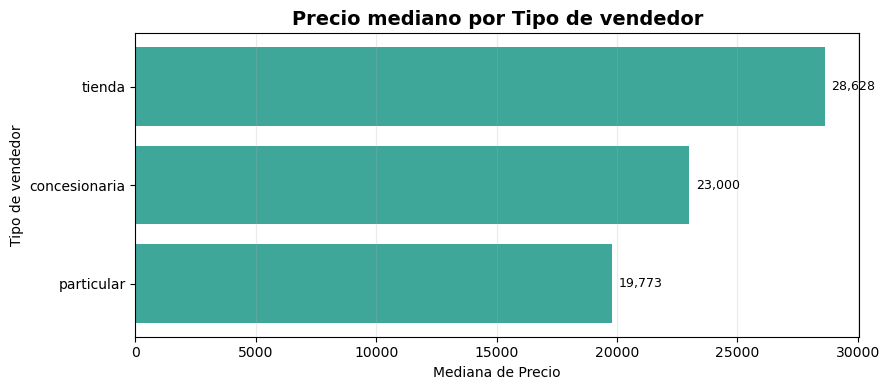

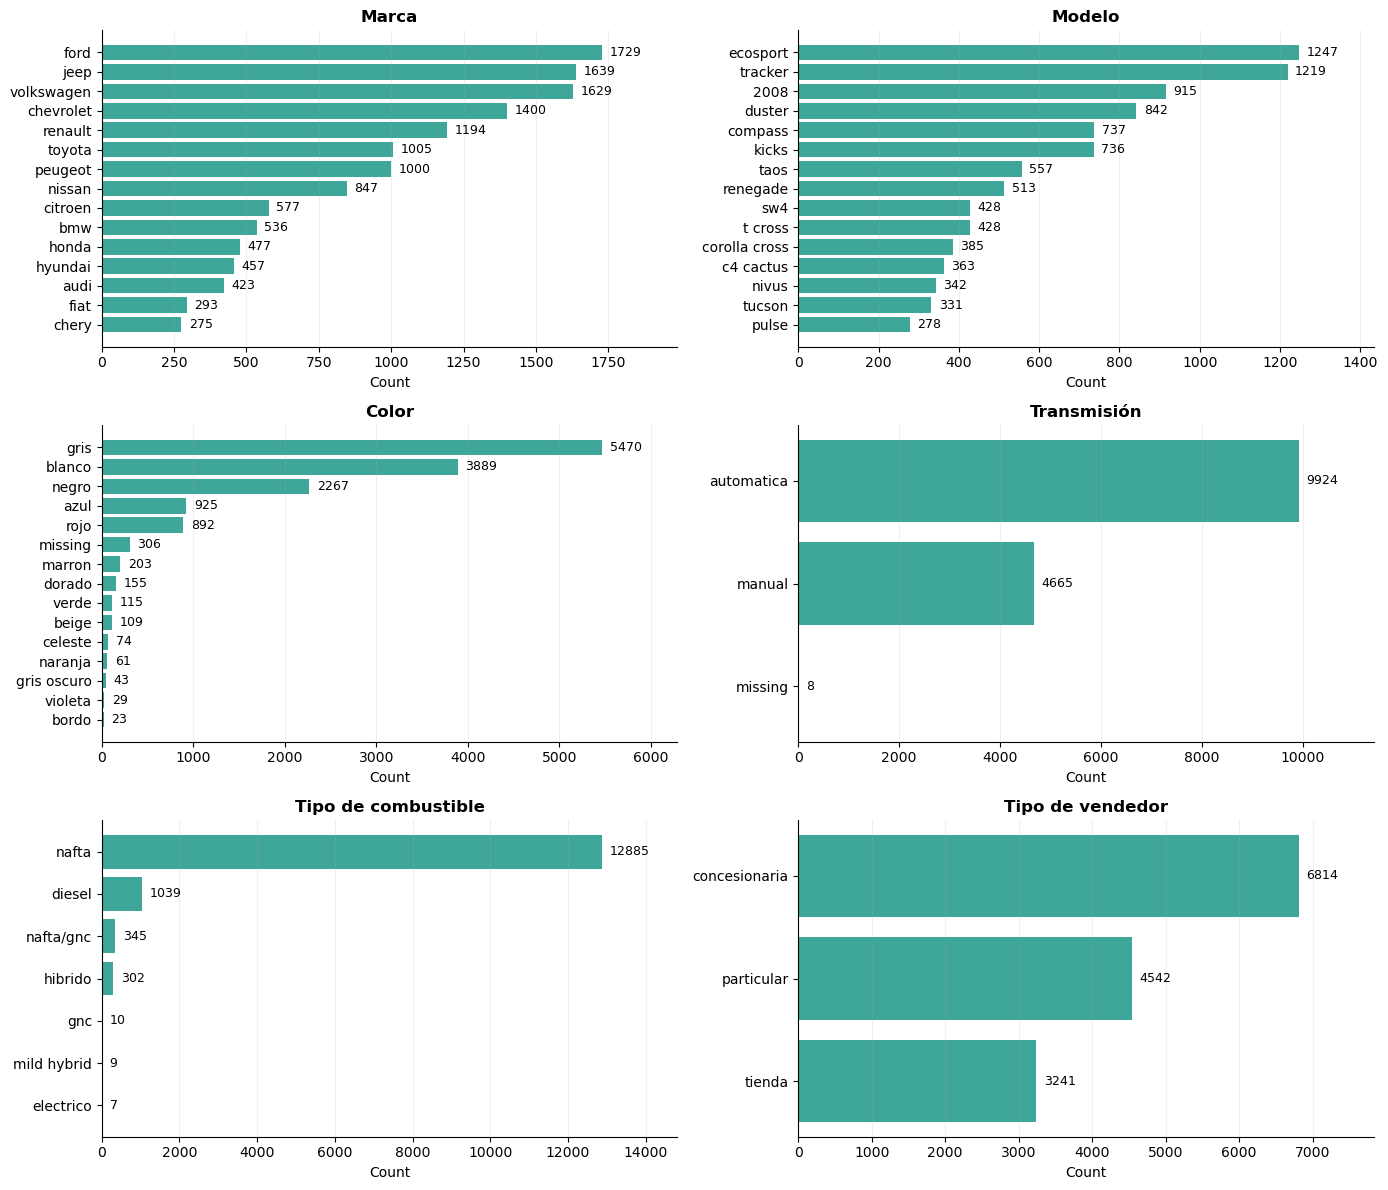

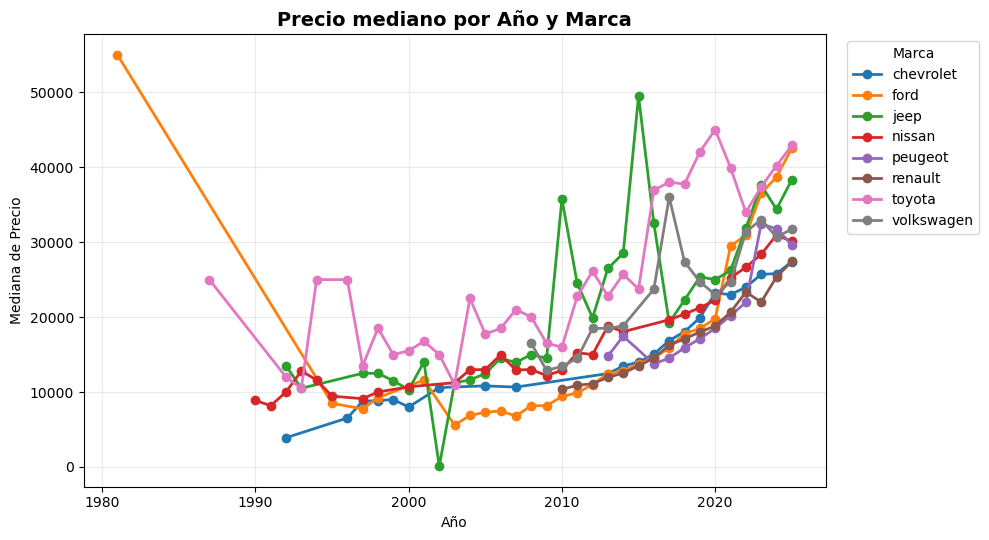

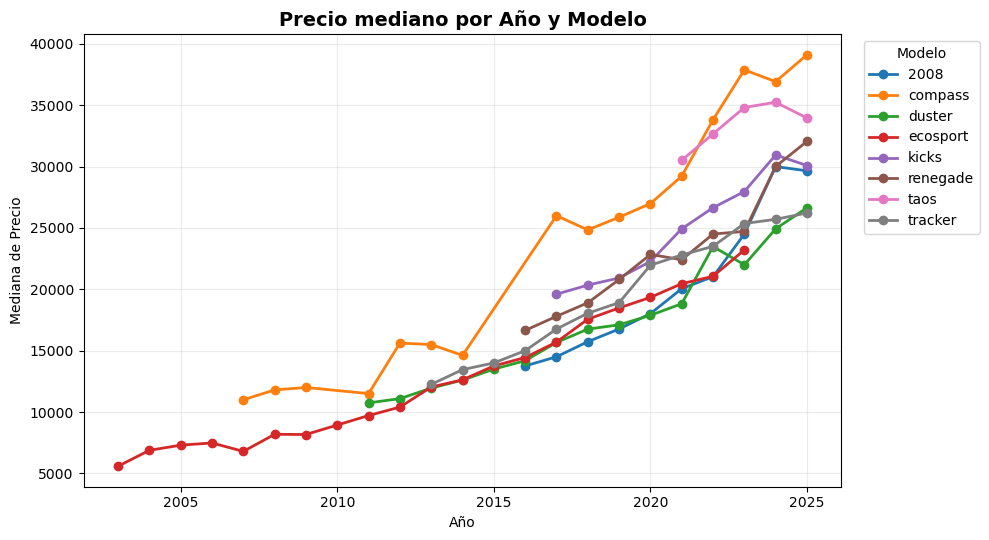

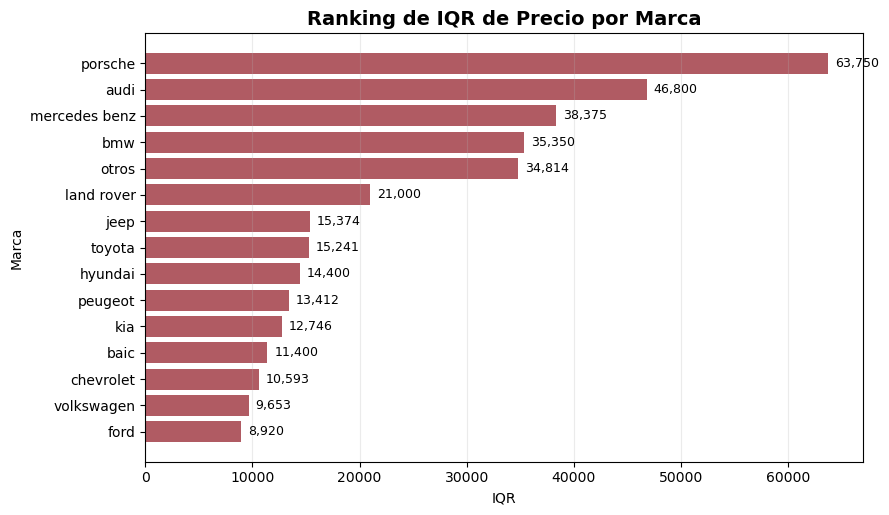

,Marca,count,q1,q3,iqr
0,porsche,54,45000.000000,108750.000000,63750.000000
1,audi,423,27900.000000,74700.000000,46800.000000
2,mercedes benz,226,31000.000000,69375.000000,38375.000000
3,bmw,536,31900.000000,67250.000000,35350.000000
4,otros,78,14936.129874,49750.000000,34813.870126
5,land rover,53,31000.000000,52000.000000,21000.000000
6,jeep,1639,23349.500000,38723.734357,15374.234357
7,toyota,1005,29659.195579,44900.000000,15240.804421
8,hyundai,457,13500.000000,27900.000000,14400.000000
9,peugeot,1000,15387.534541,28799.508750,13411.974209


In [75]:
# Post-preprocessing EDA before one-hot encoding
# Use only train to avoid using validation/test information for decisions.

train_pre_onehot = X_train.copy()
train_pre_onehot["Precio"] = y_train.values

visual.plot_price_distribution(train_pre_onehot)
visual.plot_price_distribution(train_pre_onehot, log_transform=True)

visual.plot_clean_numeric_distributions(
    train_pre_onehot,
    numeric_cols=("Año", "Kilómetros", "Puertas", "Cilindrada", "Grupo cilindrada")
)

visual.plot_price_vs_numeric(train_pre_onehot, x_col="Año", sample_size=5000)
visual.plot_price_vs_numeric(train_pre_onehot, x_col="Kilómetros", sample_size=5000)

visual.plot_year_kilometers_price_scatter(
    train_pre_onehot,
    sample_size=5000,
    km_percentile_range=None,
    price_color_percentile_range=None,
)

visual.plot_median_price_by_category(train_pre_onehot, "Marca", top_n=15, min_count=50)
visual.plot_price_boxplot_by_category(train_pre_onehot, "Marca", top_n=15, min_count=50)

visual.plot_median_price_by_category(train_pre_onehot, "Modelo", top_n=15, min_count=80)
visual.plot_median_price_by_category(train_pre_onehot, "Color", top_n=15, min_count=30)

visual.plot_median_price_by_category(train_pre_onehot, "Transmisión", min_count=30)
visual.plot_median_price_by_category(train_pre_onehot, "Tipo de combustible", min_count=30)
visual.plot_median_price_by_category(train_pre_onehot, "Tipo de vendedor", min_count=30)

visual.plot_category_frequency_after_cleaning(
    train_pre_onehot,
    columns=["Marca", "Modelo", "Color", "Transmisión", "Tipo de combustible", "Tipo de vendedor"],
    top_n=15,
)

visual.plot_median_price_by_age_lines(train_pre_onehot, group_col="Marca", top_n=8, min_count=150)
visual.plot_median_price_by_age_lines(train_pre_onehot, group_col="Modelo", top_n=8, min_count=120)

brand_iqr = visual.plot_iqr_ranking_by_category(
    train_pre_onehot,
    category_col="Marca",
    top_n=15,
    min_count=50
)

brand_iqr

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
One Hot Encoding
</h3>

Después del split, se aplica one-hot encoding a las variables categóricas. El encoder se ajusta sobre el conjunto de entrenamiento y luego se aplica al conjunto de validación usando las mismas categorías aprendidas.

Este orden evita que el conjunto de validación influya en la definición de las columnas dummy. De esta forma, el preprocesamiento respeta la separación entre train y validation.

In [64]:
categorical_cols_to_encode = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión"
]

X_train_encoded, categories_map = prep.one_hot_encoding(
    X_train,
    categorical_cols = categorical_cols_to_encode,
    train = True
)

X_val_encoded = prep.one_hot_encoding(
    X_val,
    categorical_cols = categorical_cols_to_encode,
    train = False,
    categories_map = categories_map
)

In [65]:
# X_train_encoded = X_train_encoded.copy()
# X_val_encoded = X_val_encoded.copy()

# X_train_encoded.to_csv("../data/pf_suvs_xtrain_encoded.csv", index = False)
# X_val_encoded.to_csv("../data/pf_suvs_xval_encoded.csv", index = False)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Checking preprocessed dataset
</h3>

In [66]:
fueture_pp_summary = eda.explore_features(X_train_encoded)
display(fueture_pp_summary["numeric"])

,feature,dtype,non_missing,missing,missing_%,min,max,mean,median,std,q1,q3,zero_count,outlier_count,outlier_%,unique,unique_%
0,Año,float64,14597,0,0.00,1981.0,2025.0,2018.982805,2019.0,5.539407,2016.0,2024.0,0,215,1.47,38,0.26
1,Puertas,float64,14597,0,0.00,2.0,5.0,4.964102,5.0,0.224431,5.0,5.0,0,418,2.86,4,0.03
2,Con cámara de retroceso,float64,4150,10447,71.57,0.0,1.0,0.816867,1.0,0.386822,1.0,1.0,760,760,5.21,2,0.01
3,Kilómetros,int64,14597,0,0.00,0.0,9999999.0,75018.338905,67245.0,112448.431514,0.0,116000.0,3659,154,1.06,1878,12.87
4,Cilindrada,float64,14581,16,0.11,1.0,8.0,1.820822,1.6,0.656478,1.5,2.0,0,1445,9.90,43,0.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,Tipo de combustible_nafta,int64,14597,0,0.00,0.0,1.0,0.882716,1.0,0.321770,1.0,1.0,1712,1712,11.73,2,0.01
201,Tipo de combustible_nafta/gnc,int64,14597,0,0.00,0.0,1.0,0.023635,0.0,0.151914,0.0,0.0,14252,345,2.36,2,0.01
202,Transmisión_automatica,int64,14597,0,0.00,0.0,1.0,0.679866,1.0,0.466544,0.0,1.0,4673,0,0.00,2,0.01
203,Transmisión_manual,int64,14597,0,0.00,0.0,1.0,0.319586,0.0,0.466332,0.0,1.0,9932,0,0.00,2,0.01


In [67]:
display(eda.missing_values_summary(X_train_encoded))

,column,missing_count,missing_percentage
0,Con cámara de retroceso,10447,71.57
1,Cilindrada,16,0.11


In [68]:
display(eda.unique_values_summary(X_train_encoded))

,column,unique_values,unique_pct
3,Kilómetros,1878,12.87
4,Cilindrada,43,0.29
0,Año,38,0.26
5,Grupo cilindrada,6,0.04
1,Puertas,4,0.03
...,...,...,...
200,Tipo de combustible_nafta,2,0.01
201,Tipo de combustible_nafta/gnc,2,0.01
202,Transmisión_automatica,2,0.01
203,Transmisión_manual,2,0.01


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Post-preprocessing EDA
</h3>

Luego del preprocesamiento, se vuelve a explorar la distribución de las variables principales. Esto permite evaluar cómo quedaron los datos luego de la limpieza y detectar si todavía existen valores extremos que puedan afectar el entrenamiento de los modelos.

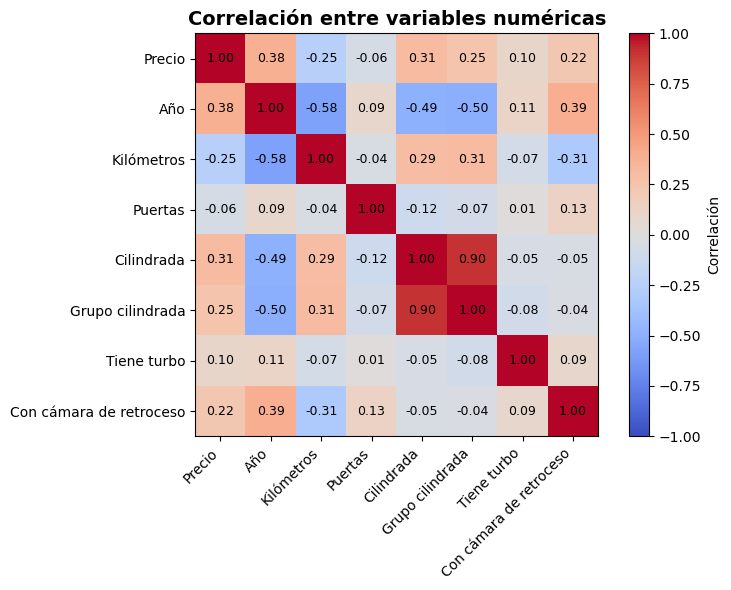

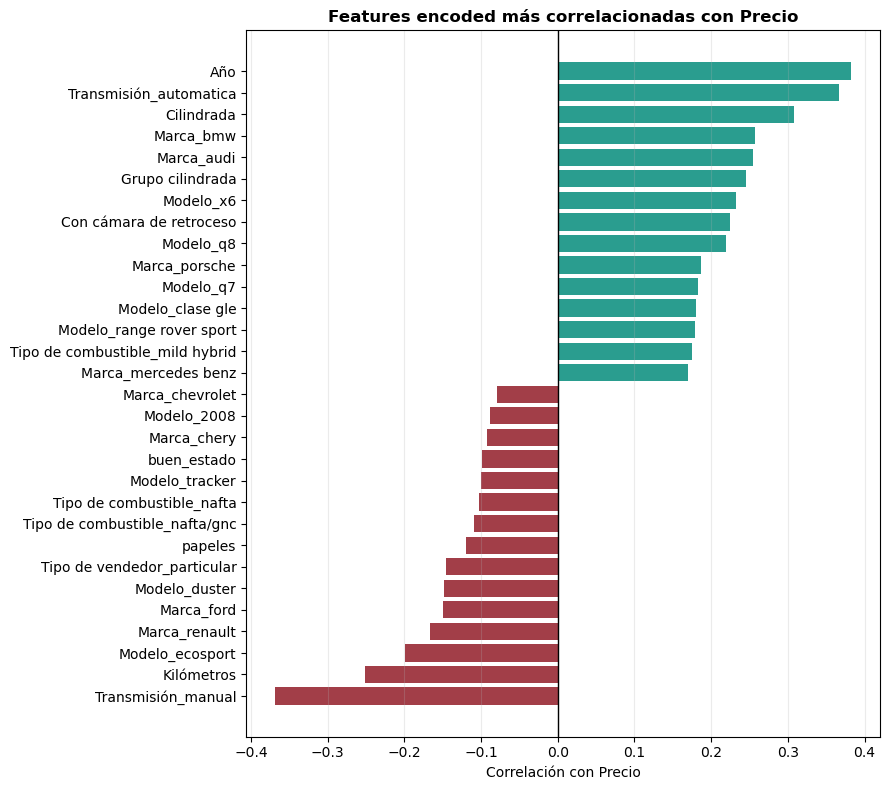

,feature,frequency
0,Tipo de combustible_nafta,0.882716
1,Transmisión_automatica,0.679866
2,sin_condicion,0.629376
3,Tipo de vendedor_concesionaria,0.466808
4,Color_gris,0.374735
5,Transmisión_manual,0.319586
6,Tipo de vendedor_particular,0.311160
7,Color_blanco,0.266425
8,Tipo de vendedor_tienda,0.222032
9,Color_negro,0.155306


,feature,frequency
173,Modelo_xc40,0.000206
174,Modelo_bronco,0.000206
175,Modelo_c3,0.000206
176,Modelo_cooper countryman,0.000206
177,Modelo_sandero stepway,0.000206
178,Modelo_sandero,0.000137
179,Modelo_defender,0.000137
180,Modelo_c4 aircross,0.000137
181,Modelo_208,0.000137
182,Modelo_samurai,0.000137


In [77]:
# Post-one-hot checks
# Here the goal is less interpretative and more model-oriented.
import matplotlib.pyplot as plt

train_encoded = X_train_encoded.copy()
train_encoded["Precio"] = y_train.values

numeric_cols = [
    "Precio",
    "Año",
    "Kilómetros",
    "Puertas",
    "Cilindrada",
    "Grupo cilindrada",
    "Tiene turbo",
    "Con cámara de retroceso",
]

numeric_cols = [col for col in numeric_cols if col in train_encoded.columns]

visual.plot_numeric_correlation_heatmap(
    train_encoded,
    numeric_cols=numeric_cols,
    add_log_price=True,
)

encoded_corr = (
    train_encoded
    .select_dtypes(include="number")
    .corr(numeric_only=True)["Precio"]
    .drop("Precio")
    .dropna()
    .sort_values()
)

top_negative = encoded_corr.head(15)
top_positive = encoded_corr.tail(15)

corr_plot = pd.concat([top_negative, top_positive])

plt.figure(figsize=(9, 8))
colors = ["#A23E48" if value < 0 else "#2A9D8F" for value in corr_plot.values]

plt.barh(corr_plot.index, corr_plot.values, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Features encoded más correlacionadas con Precio", fontweight="bold")
plt.xlabel("Correlación con Precio")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

dummy_cols = [
    col for col in train_encoded.columns
    if "_" in col and col != "Precio"
]

dummy_frequency = (
    train_encoded[dummy_cols]
    .mean()
    .sort_values(ascending=False)
    .rename("frequency")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(dummy_frequency.head(20))
display(dummy_frequency.tail(20))